# EuroCropsML: exploratory data analysis and Phase 1 class design

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**Dataset.** EuroCropsML (Reuss et al., 2025). 706,683 labelled parcels across Estonia, Latvia and Portugal, each carrying a per-parcel Sentinel-2 L1C reflectance time series for 2021 (the spatial median over the parcel pixels at every cloud-free acquisition), with a harmonised EuroCrops HCAT crop-type label.

**Purpose of this notebook.** Two things. First, to characterise the dataset as it actually sits on disk. Second, and more importantly, to settle the class design for the Phase 1 label-efficiency benchmark: which classes exist, which must be excluded, at what level of the HCAT hierarchy they should be aggregated, and how many classes each country and each country pair can actually support.

**Provenance of every number.** Unless a cell states otherwise, every count, percentage and statistic reported here is computed over the **full 706,683-parcel catalogue**, not over a sample. The heavy scans live in scripts under `results/eda/`, which write cached artefacts that this notebook loads; where a statistic is estimated from a sample (the spatial neighbour statistics and the NDVI phenology profiles) the sample size is stated in the text and recorded in the cached configuration alongside the result.

| Script | What it does | Cached artefact |
|---|---|---|
| `results/eda/_build_catalogue.py` | reads `dates` and `center` from all 706,683 `.npz` files in parallel | `data/catalogue_parcels_full.parquet`, `results/eda/cache/date_histogram.parquet` |
| `results/eda/_run_analysis.py` | general characterisation, figures 01 to 10 | `results/eda/findings.json` |
| `results/eda/_class_design.py` | class inventory, exclusion rules, aggregation, spatial and temporal statistics, figures 12 to 19 | `results/eda/cache/class_design.json`, `configs/class_scheme_eurocropsml.yaml` |
| `results/eda/_phenology.py` | NDVI phenology of the retained classes, figures 20 and 21 | `results/eda/cache/phenology_profiles.parquet` |
| `results/eda/_hcat.py` | HCAT taxonomy lookup and hierarchy helpers | `results/eda/cache/hcat/*.csv` |

**Verified on-disk format.** One `.npz` per parcel, flat in `<DATA_ROOT>/preprocess/`, named `<NUTS><parcel_id>_<HCAT code>.npz`. The keys are `data` of shape `(T, 13)` and dtype `int64` (raw Sentinel-2 L1C reflectance scaled by 10,000), `dates` of shape `(T,)` and dtype `datetime64[D]`, and `center` of shape `(2,)`, ordered `(lon, lat)` in WGS-84 degrees. The thirteen bands are in the fixed order B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B10, B11, B12, so NDVI uses index 3 (B04, red) and index 7 (B08, near infrared). Cloud filtering has already been applied by the dataset authors.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
sns.set_theme(context="notebook", style="whitegrid")

SEED = 42
np.random.seed(SEED)


def find_repo(start: Path) -> Path:
    """Walk upwards until the repository root is found."""
    for p in [start, *start.parents]:
        if (p / "CLAUDE.md").exists() or (p / ".git").exists():
            return p
    raise RuntimeError("repository root not found")


REPO = find_repo(Path.cwd().resolve())
# The data location follows the convention documented in data/README.md: the
# EUROCROPSML_DATA environment variable overrides, otherwise <repo>/data/eurocropsml.
DATA_ROOT = Path(os.environ.get("EUROCROPSML_DATA", REPO / "data" / "eurocropsml")).expanduser()
PREPROCESS_DIR = DATA_ROOT / "preprocess"

EDA = REPO / "results" / "eda"
CACHE = EDA / "cache"
FIG = EDA / "figures"
CATALOGUE = REPO / "data" / "catalogue_parcels_full.parquet"
sys.path.insert(0, str(EDA))
import _hcat  # noqa: E402  the HCAT taxonomy helper that lives beside the scripts

print("repository :", REPO)
print("DATA_ROOT  :", DATA_ROOT, "| preprocess present:", PREPROCESS_DIR.is_dir())
print("catalogue  :", CATALOGUE.name, "| present:", CATALOGUE.exists())

repository : C:\Users\darey\OneDrive - University of Twente\Documents\THESIS - ExplainedGMF4Agri
DATA_ROOT  : C:\Users\darey\OneDrive - University of Twente\Documents\THESIS - ExplainedGMF4Agri\data\eurocropsml | preprocess present: True
catalogue  : catalogue_parcels_full.parquet | present: True


In [2]:
def run_script(name: str, *args: str) -> None:
    """Run one of the results/eda scripts in a subprocess."""
    cmd = [sys.executable, str(EDA / name), *args]
    print("running", " ".join(cmd))
    subprocess.run(cmd, check=True, cwd=str(REPO))


def cached(path: Path, script: str, *args: str):
    """Load a cached artefact, computing it first if it is missing."""
    if not path.exists():
        run_script(script, *args)
    if path.suffix == ".json":
        return json.loads(path.read_text(encoding="utf-8"))
    return pd.read_parquet(path)


def show(name: str, width: int = 980) -> None:
    """Display a figure from results/eda/figures."""
    display(Image(filename=str(FIG / name), width=width))


def table(df: pd.DataFrame, n: int | None = None) -> None:
    display(df.head(n) if n else df)

## 1. On-disk inspection

Before anything else, confirm the file count and the array schema of a single parcel.

In [3]:
n_files = sum(1 for e in os.scandir(PREPROCESS_DIR) if e.name.endswith(".npz"))
print(f"{n_files:,} .npz files in {PREPROCESS_DIR}")

example = next(e.path for e in os.scandir(PREPROCESS_DIR) if e.name.endswith(".npz"))
print("example file:", Path(example).name)
with np.load(example) as z:
    for k in z.files:
        a = z[k]
        print(f"  {k:8s} shape={str(a.shape):10s} dtype={str(a.dtype):16s} first={a.ravel()[:3]}")

nuts, pid, code_ = Path(example).stem.split("_")
print(f"\nfilename decodes to NUTS region {nuts}, parcel {pid}, "
      f"HCAT class {code_} = {_hcat.name_of(code_).replace('_', ' ')} "
      f"(hierarchical level {_hcat.hcat_level(code_)})")

706,683 .npz files in C:\Users\darey\OneDrive - University of Twente\Documents\THESIS - ExplainedGMF4Agri\data\eurocropsml\preprocess
example file: EE001_19990038_3302000000.npz
  data     shape=(39, 13)   dtype=int64            first=[1328 1007  733]
  dates    shape=(39,)      dtype=datetime64[D]    first=['2021-04-07' '2021-04-17' '2021-04-19']
  center   shape=(2,)       dtype=float64          first=[25.36743556 59.08983784]

filename decodes to NUTS region EE001, parcel 19990038, HCAT class 3302000000 = pasture meadow grassland grass (hierarchical level 3)


## 2. The parcel catalogue, over all 706,683 parcels

The proposal-phase version of this notebook scanned a random sample of 30,000 parcels, which is roughly 4.2 % of the dataset. That is adequate for a first look but not for class-design decisions, because the decisions turn on the size of the rarer classes, which is precisely where a 4 % sample is least reliable.

`results/eda/_build_catalogue.py` therefore reads `dates` and `center` from every file. Reading 706,683 compressed archives is bound by input and output rather than by computation, so the scan is parallelised with `concurrent.futures.ProcessPoolExecutor`. The wall-clock time and the configuration are recorded beside the output.

In [4]:
cfg = cached(CACHE / "catalogue_config.json", "_build_catalogue.py")
cat = cached(CATALOGUE, "_build_catalogue.py")
cat["hcat"] = cat["hcat"].astype(str)

print(json.dumps(cfg, indent=2))
print()
print(f"catalogue: {len(cat):,} rows x {cat.shape[1]} columns")
print(cat.dtypes.to_string())
table(cat.head(3))

{
  "script": "results/eda/_build_catalogue.py",
  "preprocess_dir": "C:\\Users\\darey\\OneDrive - University of Twente\\Documents\\THESIS - ExplainedGMF4Agri\\data\\eurocropsml\\preprocess",
  "n_files_listed": 706683,
  "n_parcels_catalogued": 706683,
  "is_full_scan": true,
  "sample_limit": null,
  "random_seed": 42,
  "workers": 16,
  "chunk_size": 1000,
  "seconds_listing": 1.6,
  "seconds_scanning": 901.7,
  "seconds_total": 905.7,
  "python": "3.11.9",
  "numpy": "2.4.4",
  "pandas": "2.3.3"
}

catalogue: 706,683 rows x 22 columns
path                   object
country                object
nuts                   object
parcel_id      string[python]
hcat                   object
n_timesteps             int32
first_date     datetime64[ns]
last_date      datetime64[ns]
lat                   float64
lon                   float64
m01                     int16
m02                     int16
m03                     int16
m04                     int16
m05                     int16
m06  

,path,country,nuts,parcel_id,hcat,n_timesteps,first_date,last_date,lat,lon,m01,m02,m03,m04,m05,m06,m07,m08,m09,m10,m11,m12
0,C:\Users\darey\OneDrive - University of Twente...,Estonia,EE001,19990038,3302000000,39,2021-04-07,2021-11-20,59.089838,25.367436,0,0,0,5,5,8,8,2,4,6,1,0
1,C:\Users\darey\OneDrive - University of Twente...,Estonia,EE001,19990039,3302000000,40,2021-04-07,2021-11-20,59.087647,25.358685,0,0,0,5,5,9,7,2,5,6,1,0
2,C:\Users\darey\OneDrive - University of Twente...,Estonia,EE001,19990040,3302000000,41,2021-02-28,2021-11-20,59.087844,25.361072,0,1,0,7,5,9,5,2,5,6,1,0


The scan completed in 906 seconds of wall-clock time (roughly fifteen minutes) using sixteen worker processes, at about 780 parcels per second. A full rebuild is therefore cheap enough to repeat whenever the exclusion rules change, and nothing in the remainder of this notebook needs to touch the raw `.npz` files again except the phenology sampling in section 6.

The catalogue carries one row per parcel with the file path, the country, the full NUTS code from the filename, the parcel identifier, the HCAT code held as a string (the leading digits are significant, so it must never be stored as an integer), the number of cloud-free observations, the first and last acquisition dates, the centroid latitude and longitude, and twelve columns `m01` to `m12` counting the observations that fall in each calendar month. The monthly columns exist so that the coverage of a fixed monthly-grid resample, which is one of the two raw-feature baselines, can be assessed without a second pass over the files.

## 3. General characterisation

Figures 01 to 10 are produced by `results/eda/_run_analysis.py` from the full catalogue, and every class is labelled with its HCAT crop name rather than its numeric code.

source: full catalogue, data/catalogue_parcels_full.parquet | full dataset: True


,parcels,share_pct
Estonia,175906,24.89
Latvia,431143,61.01
Portugal,99634,14.10


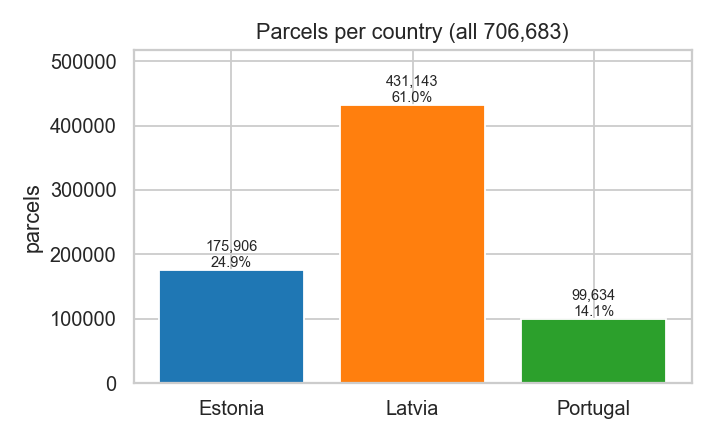

In [5]:
findings = cached(EDA / "findings.json", "_run_analysis.py")
print("source:", findings["source"], "| full dataset:", findings["is_full_dataset"])
counts = pd.DataFrame({
    "parcels": findings["parcels_per_country"],
    "share_pct": findings["parcels_per_country_pct"]})
table(counts)
show("01_parcels_per_country.png", width=520)

### 3.1 Countries

Over the full dataset Latvia holds 431,143 parcels (61.0 %), Estonia 175,906 (24.9 %) and Portugal 99,634 (14.1 %). Latvia is larger than Estonia by a factor of 2.5 and larger than Portugal by a factor of 4.3.

The consequence for Phase 1 is that Portugal is the binding constraint. Any protocol that requires a fixed number of classes with a fixed minimum size per class will run out of classes in Portugal long before it does so in Latvia, and the cross-country transfer experiments that involve Portugal will be restricted to a much smaller shared label space than the Estonia to Latvia pair.

,hcat,crop_name,n,share_pct
0,3302000000,pasture meadow grassland grass,315519,44.65
1,3301010101,winter common soft wheat,64325,9.10
2,3301010500,oats,30636,4.34
3,3399000000,not known and other,29573,4.18
4,3301010102,spring common soft wheat,27046,3.83
5,3301010402,spring barley,23670,3.35
6,3301990000,other arable land crops,21550,3.05
7,3301110000,fallow land not crop,20666,2.92
8,3303050000,olive plantations,18692,2.65
9,3301060401,winter rapeseed rape,17847,2.53


distinct HCAT classes in the full dataset: 176
cumulative coverage: {'top_k_for_50pct': 2, 'top_k_for_80pct': 10, 'top_k_for_95pct': 26, 'top_k_for_99pct': 57}


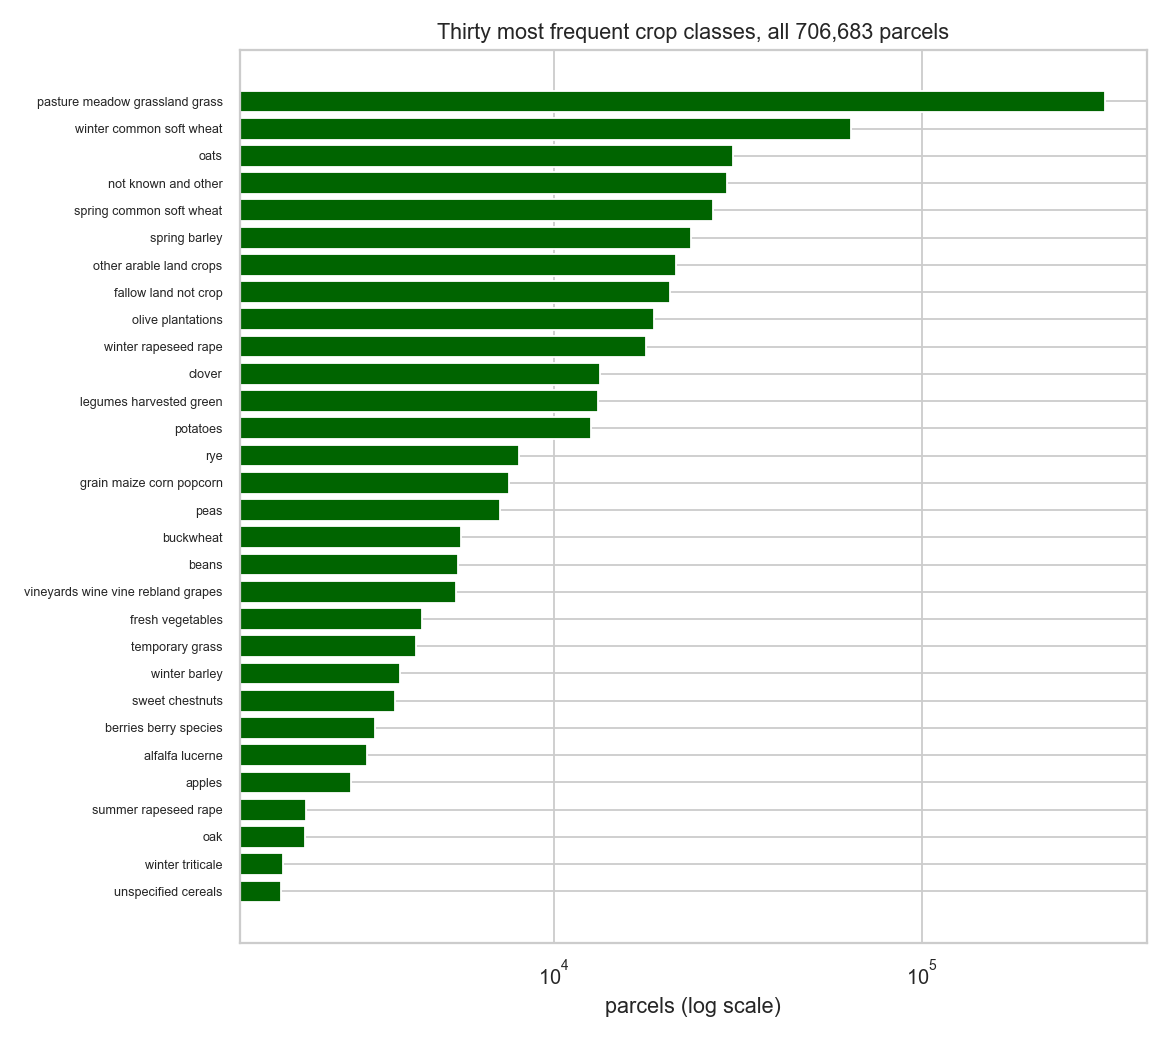

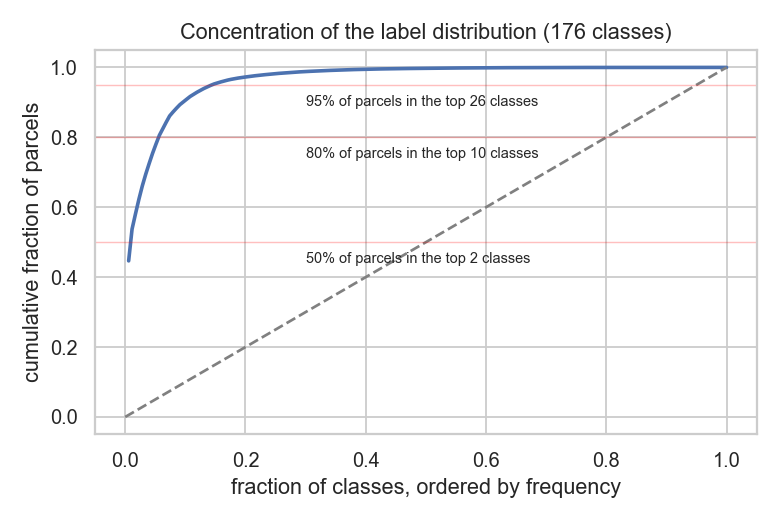

In [6]:
top = pd.DataFrame(findings["top10_classes"])
table(top)
print("distinct HCAT classes in the full dataset:", findings["n_distinct_classes"])
print("cumulative coverage:", findings["class_coverage"])
show("02_top30_classes.png", width=700)
show("04_lorenz_classes.png", width=560)

### 3.2 The label distribution is extremely concentrated

The full dataset contains 176 distinct HCAT classes. Two classes cover half of all parcels, ten cover 80 %, twenty-six cover 95 % and fifty-seven cover 99 %; the remaining 119 classes share the last 1 %.

The single largest class, HCAT 3302000000, pasture, meadow, grassland and grass, holds 315,519 parcels, which is 44.6 % of the dataset. The second largest, HCAT 3301010101, winter common soft wheat, holds 64,325 parcels (9.1 %).

Two corrections to the proposal-phase reading of this table are worth recording, because they were based on guessed crop names rather than on the HCAT taxonomy. HCAT 3301010101 is **winter** common soft wheat and 3301010102 is **spring** common soft wheat, not the other way round. HCAT 3301110000 is **fallow land**, not legumes, and HCAT 3301090300 is **legumes harvested green**, not fallow. Every figure in this notebook now draws its names from the EuroCrops HCAT2 taxonomy directly, so this class of error cannot recur.

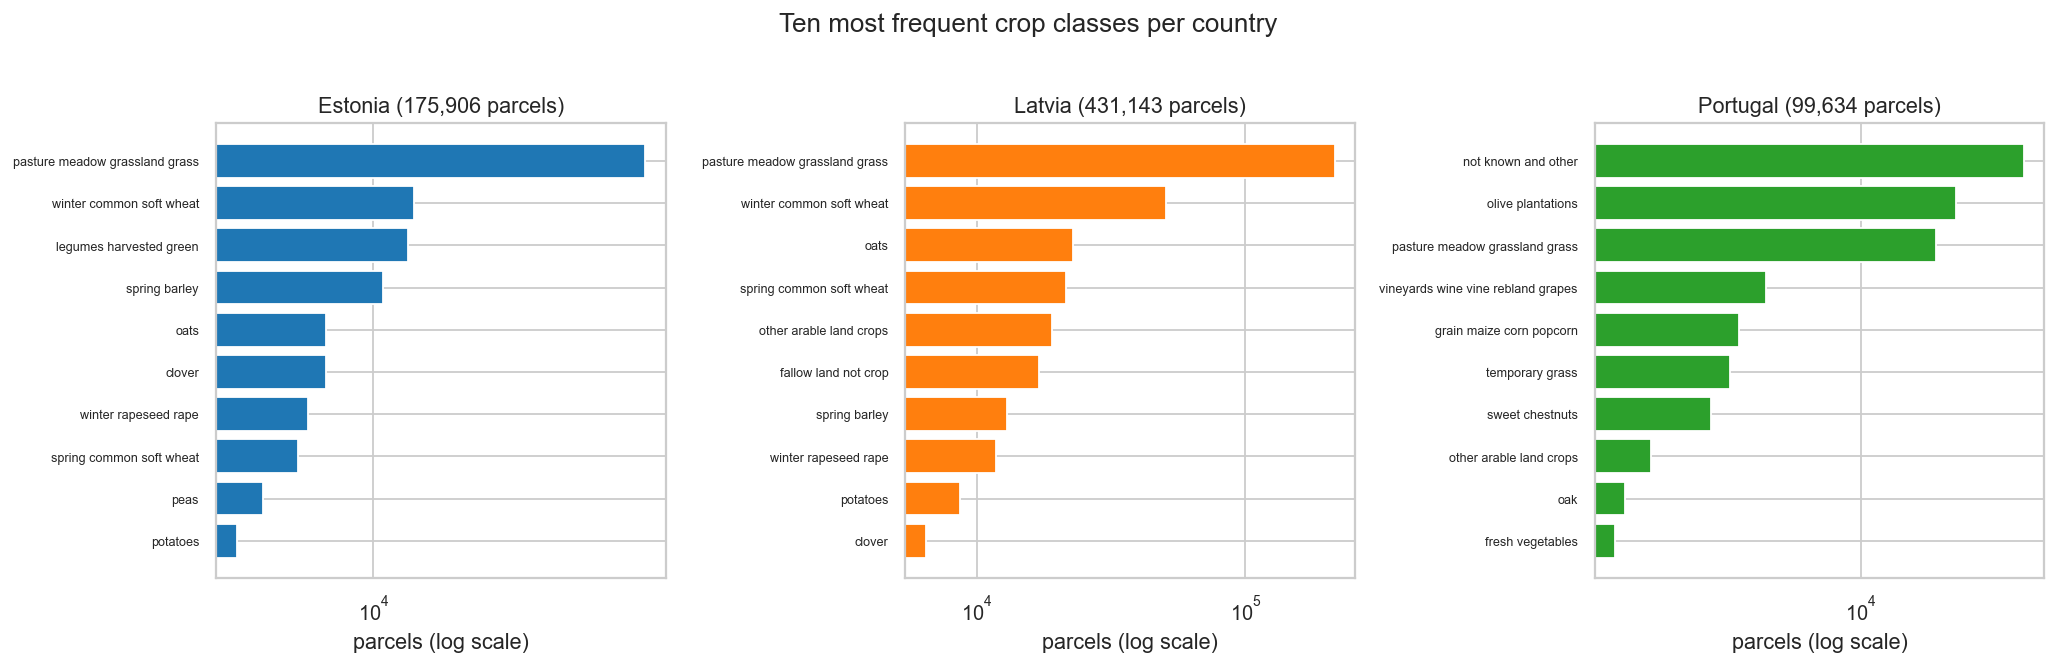

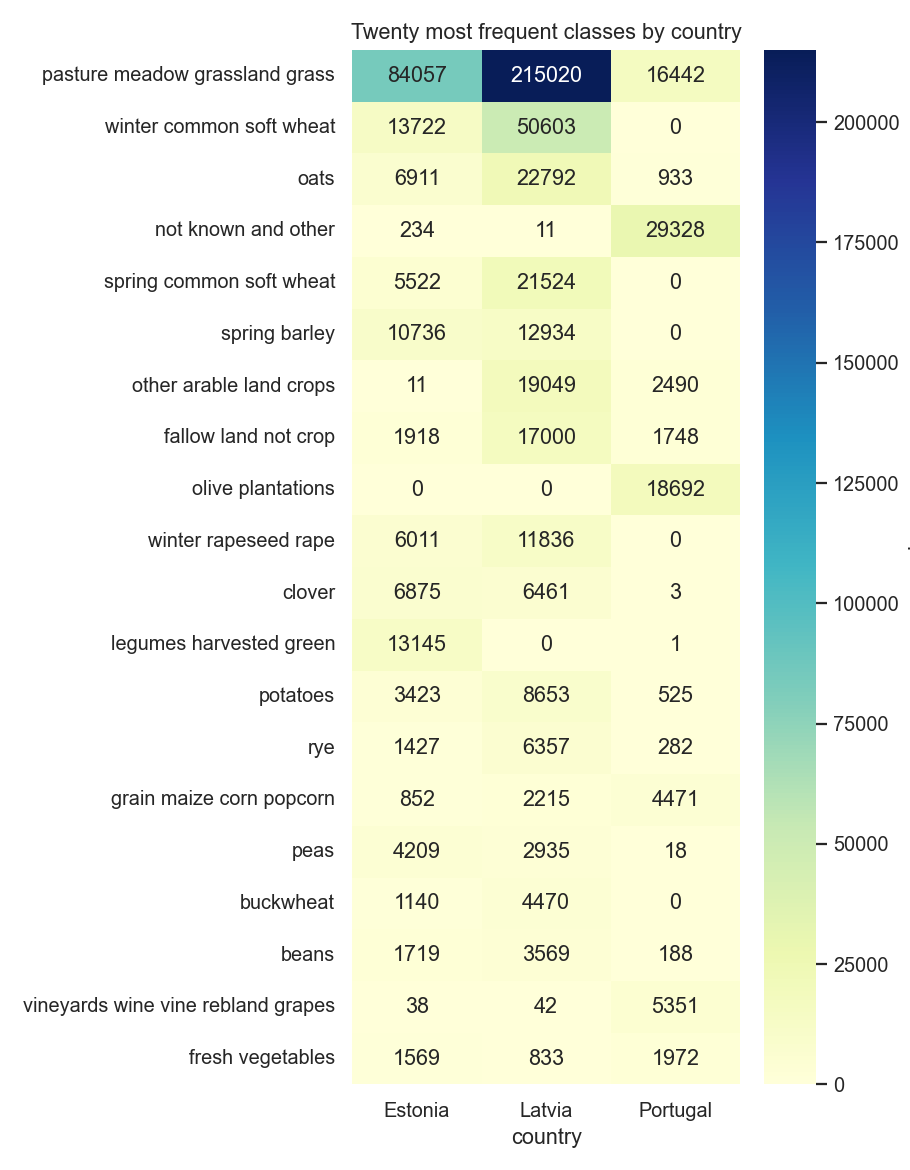

of the twenty most frequent classes, present in all three countries: 13


In [7]:
show("03_top10_per_country.png", width=1000)
show("05_class_country_heatmap.png", width=620)
print("of the twenty most frequent classes, present in all three countries:",
      findings["top20_classes_present_in_all_three"])

### 3.3 The three countries have almost disjoint crop mixes

Estonia and Latvia share the Baltic temperate mix: grassland, then winter and spring soft wheat, spring barley, oats, clover and winter rapeseed. Portugal is Mediterranean and largely perennial: olive plantations, grassland of the montado type, vineyards, grain maize, temporary grass and sweet chestnuts.

Of the twenty most frequent classes in the dataset, thirteen occur in all three countries at all, but presence is not the same as usability: several of those thirteen have only a handful of parcels in one of the three. Four of Estonia's and Latvia's largest arable classes, namely winter common soft wheat, spring common soft wheat, spring barley and winter rapeseed, have exactly zero parcels in Portugal. Portugal's own largest class in the raw data, HCAT 3399000000 (not known and other), is effectively Portuguese only. This is examined in section 4.2, because it turns out not to be a crop at all.

{
  "Estonia": {
    "n_nuts_regions": 5,
    "top3": {
      "EE008": 79054,
      "EE004": 45053,
      "EE009": 33335
    }
  },
  "Latvia": {
    "n_nuts_regions": 6,
    "top3": {
      "LV005": 150203,
      "LV008": 91874,
      "LV003": 72676
    }
  },
  "Portugal": {
    "n_nuts_regions": 23,
    "top3": {
      "PT11E": 23476,
      "PT16E": 9019,
      "PT16H": 6393
    }
  }
}


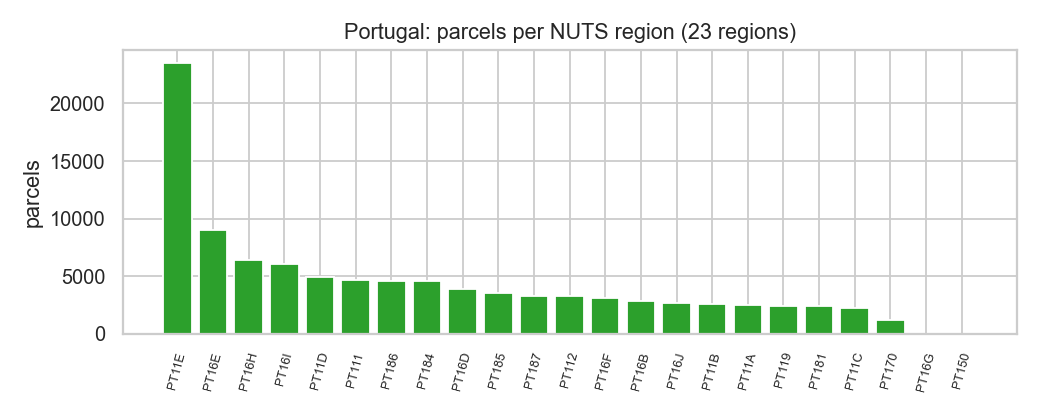

In [8]:
print(json.dumps(findings["nuts_summary"], indent=2))
show("06_nuts_portugal.png", width=760)

### 3.4 NUTS regions

Estonia is divided into five NUTS regions in this dataset, Latvia into six and Portugal into twenty-three. Portugal is therefore the only country in which the published NUTS partition is fine enough to support a meaningful within-country geographic hold-out; for Estonia and Latvia a grid-based spatial blocking will be required instead, which is quantified in section 5.1.

{
  "Estonia": {
    "mean": 46.65,
    "median": 44,
    "min": 7,
    "max": 216,
    "std": 9.83
  },
  "Latvia": {
    "mean": 45.76,
    "median": 45,
    "min": 9,
    "max": 148,
    "std": 6.55
  },
  "Portugal": {
    "mean": 60.15,
    "median": 49,
    "min": 1,
    "max": 146,
    "std": 23.0
  }
}


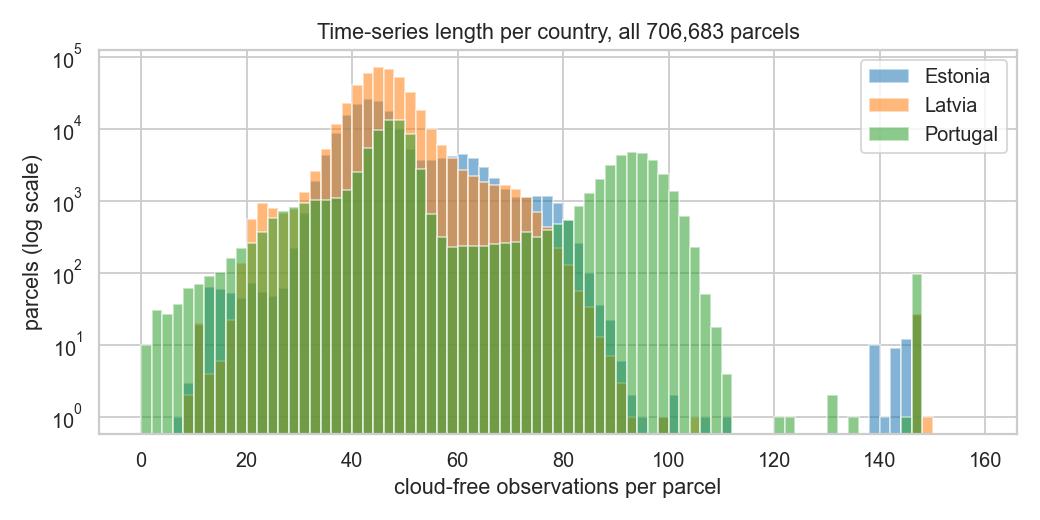

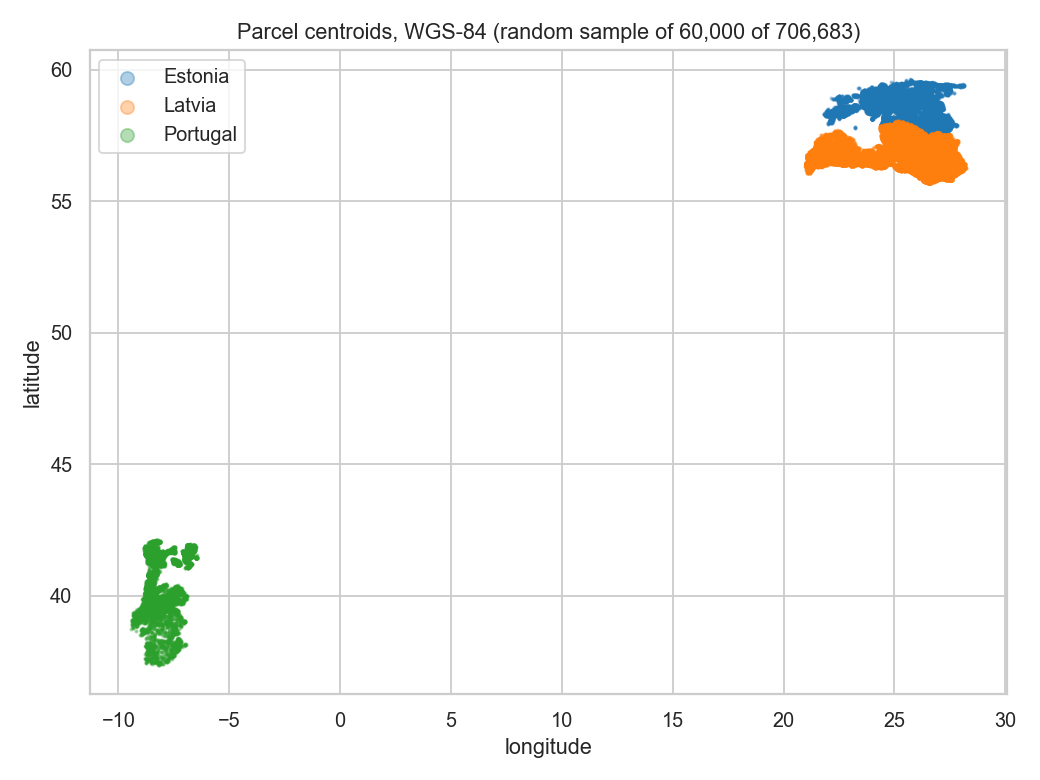

{
  "Estonia": {
    "lon_min": 21.78,
    "lon_max": 28.156,
    "lat_min": 57.518,
    "lat_max": 59.645
  },
  "Latvia": {
    "lon_min": 20.984,
    "lon_max": 28.214,
    "lat_min": 55.676,
    "lat_max": 58.072
  },
  "Portugal": {
    "lon_min": -9.453,
    "lon_max": -6.468,
    "lat_min": 37.322,
    "lat_max": 42.137
  }
}


In [9]:
print(json.dumps(findings["timestep_stats"], indent=2))
show("07_timestep_hist.png", width=700)
show("08_centroids.png", width=620)
print(json.dumps(findings["centroid_bounds"], indent=2))

### 3.5 Time-series length and geography

Over the full dataset the mean number of cloud-free observations per parcel is 46.7 in Estonia (median 44, range 7 to 216), 45.8 in Latvia (median 45, range 9 to 148) and 60.2 in Portugal (median 49, range 1 to 146). Portugal is right-skewed: most Portuguese parcels sit in the same 40 to 50 band as the Baltics, but a long tail reaches beyond 100 observations because the Mediterranean south retains far more cloud-free acquisitions.

The proposal-phase figure, taken from the 30,000-parcel sample, reported a minimum of 10 observations for Estonia and Latvia. Over the full dataset the true minima are 7 for Estonia and 9 for Latvia, and Portugal reaches down to a single observation. The cost of a minimum-length rule is quantified in section 4.3.

The centroids fall exactly where they should. Estonia and Latvia form one contiguous Baltic mass between 55.7 and 59.6 degrees north, Portugal a separate Iberian cluster between 37.3 and 42.1 degrees north. All Portuguese centroids lie between 9.45 and 6.47 degrees west, so the Azores and Madeira are not represented in this release, which simplifies the spatial blocking considerably.

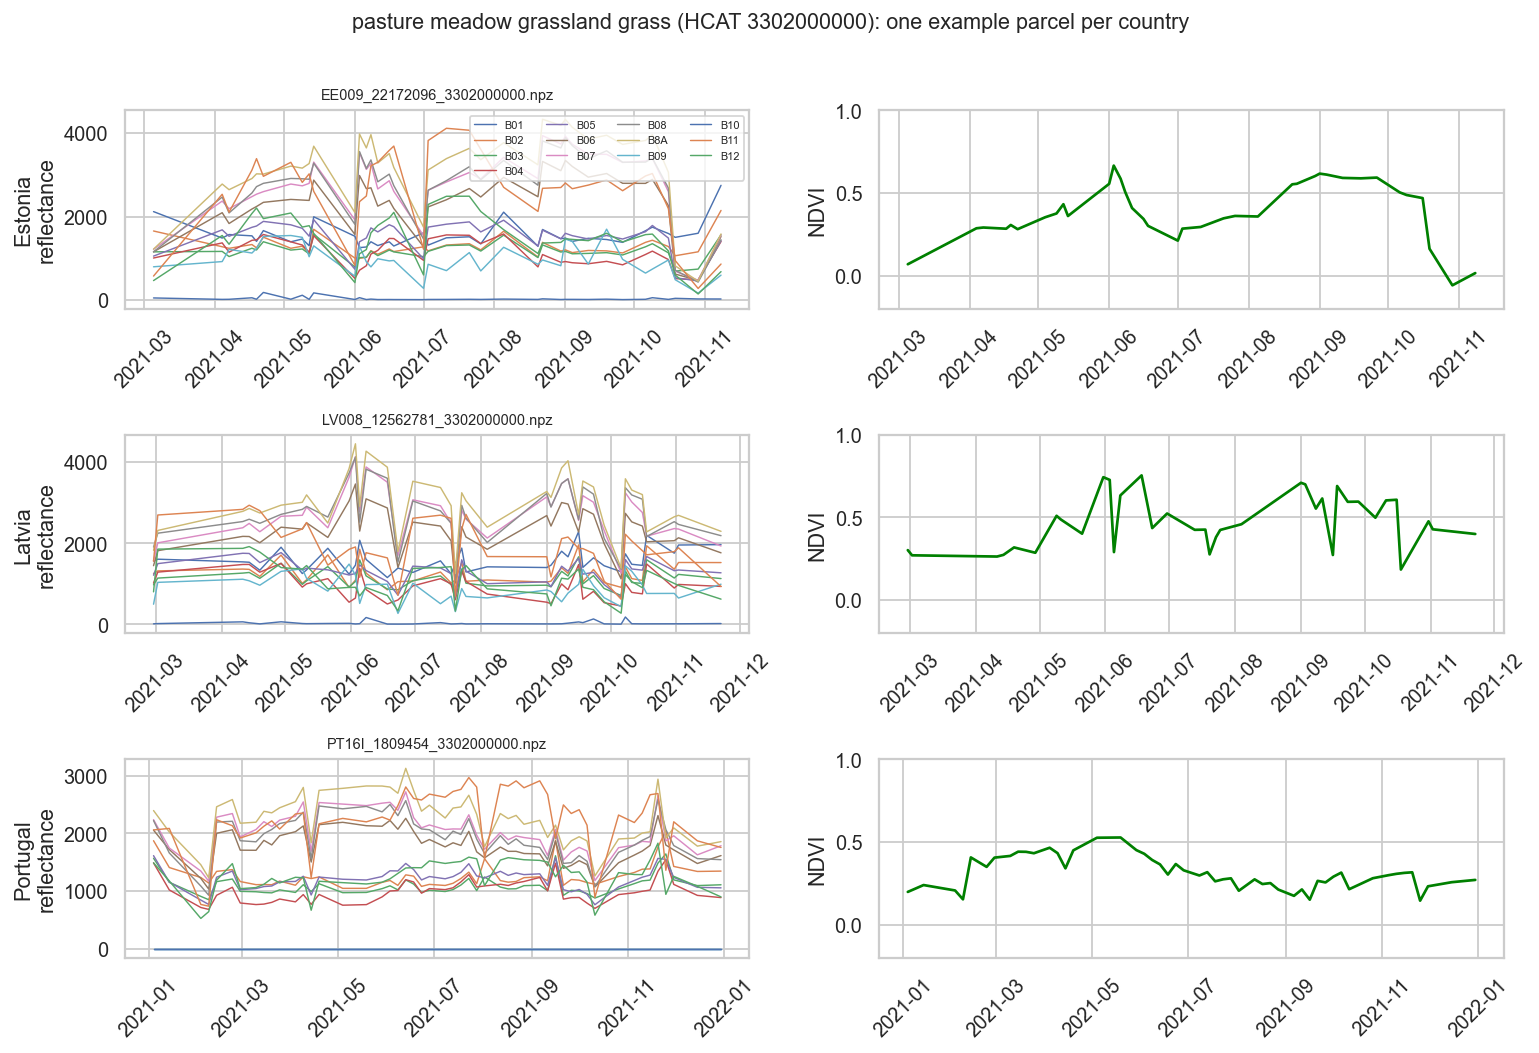

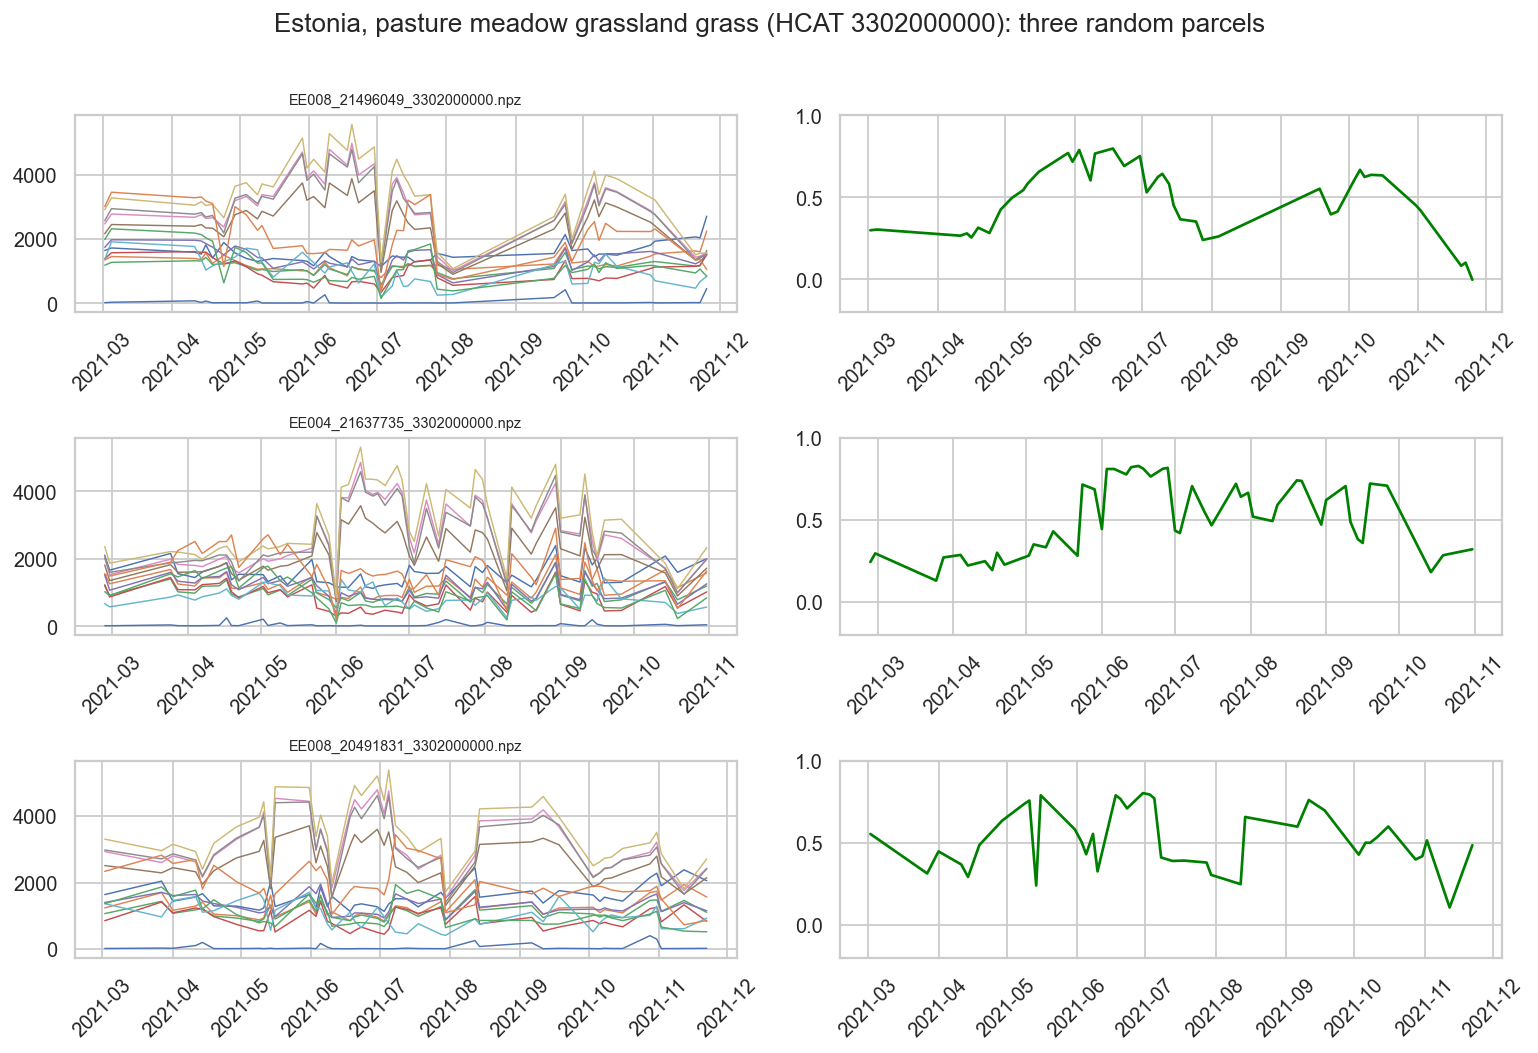

In [10]:
show("09_ts_class_3302000000.png", width=860)
show("10_intraclass_variance.png", width=860)

### 3.6 Single-parcel time series

The grassland panel shows the same HCAT class behaving very differently in the two climates. The Baltic parcels follow the textbook northern-temperate pattern, with a single broad summer peak and almost no usable winter observations, whereas the Portuguese parcel is already green in February, plateaus through spring and autumn and never falls to Baltic winter levels. The intra-class panel shows that three random Estonian grassland parcels already differ visibly from one another, which sets the noise floor any classifier must beat and argues for holding out whole parcels rather than individual observations.

## 4. Class design

This section answers the three class-design questions directly from the full catalogue: what classes exist, what must be excluded, and how the HCAT hierarchy should be aggregated. All of it is computed by `results/eda/_class_design.py`, which also writes the machine-readable scheme to `configs/class_scheme_eurocropsml.yaml`.

In [11]:
cd = cached(CACHE / "class_design.json", "_class_design.py")
inventory = cached(CACHE / "class_inventory.parquet", "_class_design.py")

print("parcels scanned:", f"{cd['n_parcels']:,}", "| full dataset")
print("distinct classes:", cd["n_distinct_classes"],
      "| classes with no name in the HCAT2 taxonomy:", cd["n_classes_unresolved_name"])
print("classes present per country:", cd["classes_per_country"])
print("classes per hierarchical level:", cd["level_distribution"])
table(inventory[["hcat", "crop_name", "level", "n_estonia", "n_latvia",
                 "n_portugal", "n_total", "share_pct", "n_countries"]], 25)

parcels scanned: 706,683 | full dataset
distinct classes: 176 | classes with no name in the HCAT2 taxonomy: 0
classes present per country: {'Estonia': 127, 'Latvia': 103, 'Portugal': 79}
classes per hierarchical level: {'3': 4, '4': 35, '5': 92, '6': 45}


,hcat,crop_name,level,n_estonia,n_latvia,n_portugal,n_total,share_pct,n_countries
0,3302000000,pasture meadow grassland grass,3,84057,215020,16442,315519,44.647883,3
1,3301010101,winter common soft wheat,6,13722,50603,0,64325,9.102384,2
2,3301010500,oats,5,6911,22792,933,30636,4.335183,3
3,3399000000,not known and other,3,234,11,29328,29573,4.184762,3
4,3301010102,spring common soft wheat,6,5522,21524,0,27046,3.827176,2
5,3301010402,spring barley,6,10736,12934,0,23670,3.349451,2
6,3301990000,other arable land crops,4,11,19049,2490,21550,3.049458,3
7,3301110000,fallow land not crop,4,1918,17000,1748,20666,2.924366,3
8,3303050000,olive plantations,4,0,0,18692,18692,2.645033,1
9,3301060401,winter rapeseed rape,6,6011,11836,0,17847,2.525460,2


### 4.1 What classes do we have?

The full class inventory, one row per HCAT code with its crop name, hierarchical level, per-country counts, total and share, is cached at `results/eda/cache/class_inventory.parquet` and mirrored as a CSV for reading outside Python. The table above shows the twenty-five largest entries.

The dataset contains 176 distinct HCAT codes and every one of them resolves to a name in the EuroCrops HCAT2 taxonomy, so there are no orphan codes. Estonia declares 127 distinct classes, Latvia 103 and Portugal 79. By hierarchical level the codes split into 4 at level 3, 35 at level 4, 92 at level 5 and 45 at level 6, so the published labels are a mixture of depths rather than a flat set at one depth. This matters for aggregation and is taken up in section 4.5.

The HCAT code is a hierarchical path of ten digits whose informative prefix lengths are 1, 2, 4, 6, 8 and 10, so truncating to one of those lengths and re-padding with zeros climbs the tree. For example 3301010101 (winter common soft wheat) rolls up to 33010101 (common soft wheat), then 330101 (cereal), then 3301 (arable crops), then 33 (crop type).

In [12]:
nc = pd.DataFrame(cd["non_crop_classes"])
table(nc[["hcat", "crop_name", "n_estonia", "n_latvia", "n_portugal",
          "n_total", "share_pct", "reason"]])
print(f"\nparcels removed by the catch-all and non-crop rules: "
      f"{cd['non_crop_parcels_total']:,} ({cd['non_crop_parcels_pct']} % of the dataset)")
print("\nclasses whose HCAT name itself signals a placeholder:")
table(pd.DataFrame(cd["suspicious_named_classes"])[
    ["hcat", "crop_name", "n_estonia", "n_latvia", "n_portugal", "n_total", "share_pct"]])

,hcat,crop_name,n_estonia,n_latvia,n_portugal,n_total,share_pct,reason
0,3399000000,not known and other,234,11,29328,29573,4.184762,not known and other; a level-3 catch-all that ...
1,3301990000,other arable land crops,11,19049,2490,21550,3.049458,other arable land crops; a catch-all for mixed...
2,3301110000,fallow land not crop,1918,17000,1748,20666,2.924366,"fallow land, a land status rather than a crop"
3,3306060000,oak,0,0,2106,2106,0.298012,"tree, wood and forest; forestry rather than an..."
4,3301011500,unspecified cereals,127,1687,0,1814,0.256692,unspecified cereals; species unresolved
5,3303080700,wire bush,0,0,967,967,0.136836,wire bush; the Portuguese declarations behind ...
6,3303120000,unspecified permanent crops,0,0,819,819,0.115894,unspecified permanent crops; declared as mixed...
7,3306000000,tree wood forest,3,3,706,712,0.100752,"tree, wood and forest; forestry rather than an..."
8,3306080000,willows osiers,5,206,0,211,0.029858,"tree, wood and forest; forestry rather than an..."
9,3301019900,other cereals,21,0,125,146,0.020660,other cereals; species unresolved



parcels removed by the catch-all and non-crop rules: 78,710 (11.14 % of the dataset)

classes whose HCAT name itself signals a placeholder:


,hcat,crop_name,n_estonia,n_latvia,n_portugal,n_total,share_pct
0,3399000000,not known and other,234,11,29328,29573,4.184762
1,3301990000,other arable land crops,11,19049,2490,21550,3.049458
2,3301110000,fallow land not crop,1918,17000,1748,20666,2.924366
3,3301011500,unspecified cereals,127,1687,0,1814,0.256692
4,3303120000,unspecified permanent crops,0,0,819,819,0.115894
5,3301019900,other cereals,21,0,125,146,0.020660
6,3301069900,other industrial crops,23,0,0,23,0.003255
7,3303990000,other permanent crops plantations,11,0,5,16,0.002264


In [13]:
print("national declarations behind the catch-all and grassland codes "
      "(EuroCrops country mapping files, 2021):")
for code_, per_country in cd["catch_all_national_declarations"].items():
    print(f"\n{code_}  {_hcat.name_of(code_).replace('_', ' ')}")
    for c, names in per_country.items():
        if names:
            print(f"   {c}: " + "; ".join(n[:70] for n in names[:6]))

national declarations behind the catch-all and grassland codes (EuroCrops country mapping files, 2021):

3399000000  not known and other
   Estonia: Birdsfoot trefoil (100%); Groundcherry ; Phacelia tanacetifolia; Phacelia tanacetifolia undersown with legumes
   Latvia: Area where the proportion of naturally sown plants exceeds 40% the num; Guilder rose
   Portugal: ELEGIBLE LANDSCAPE FEATURES - WATER LINES; association of nitrogen-fixing plants

3301990000  other arable land crops
   Estonia: Winter triticale with the exception of leguminous crops; other technical culture
   Latvia: Different crops on a small area of arable land or several crops grown ; Other crops not elsewhere specified sown as a mixture of crops on arab; Other crops sown on pure arable land
   Portugal: ANNUAL AND OTHER CULT. FORAGE ANNUALS; CORN; ANNUAL AND OTHER CULT. FORAGE ANNUALS; CORN; OTHER VEGETABLES; ANNUAL CONSOCIATIONS AND OTHER CULT. FORAGE AN; MAIZE; BEANS; POTATOES; ANNUAL INTERCROPS AND OTHER CROPS. 

### 4.2 What needs to be cut off? Non-crop and catch-all classes

Thirteen HCAT codes, plus the whole `3306` forestry branch, are recommended for exclusion. Together they account for 78,710 parcels, or 11.1 % of the dataset. The justification for each is not that the name looks unhelpful but that the national declarations mapped onto it are not a crop.

**HCAT 3399000000, not known and other (29,573 parcels, 29,328 of them Portuguese).** This is a level-3 code, a sibling of arable crops and grassland rather than a leaf. The Portuguese declarations mapped onto it include "eligible landscape features, water lines" and rows whose original name is missing entirely, so it is simultaneously a residual bucket and the destination for declarations with no HCAT equivalent. It is also 29.4 % of all Portuguese parcels. Training or evaluating on it would mean asking a classifier to recognise "everything the harmonisation could not place", which is not a crop type and not a transferable concept. It must be dropped, and dropping it is the single largest reason why Portugal loses more than a third of its parcels to the filters.

**HCAT 3301990000, other arable land crops (21,550 parcels).** The Portuguese declarations behind it are multi-crop intercropping strings such as "pumpkins and courgettes; chickpea; corn; bean; potato; other vegetables; annual and other cultivated forage annuals", and the Latvian ones are explicitly "other crops not elsewhere specified". This is a mixture label, not a class.

**HCAT 3301110000, fallow land (20,666 parcels).** Fallow is a land status rather than a crop. It is retained in the configuration file as a borderline class that may be reinstated if the task is later framed as land use rather than crop type, since it is one of the larger Latvian classes.

**The `3306` branch, tree, wood and forest (3,136 parcels).** Oak accounts for 2,106 of these, all Portuguese, and the declarations are cork oak and holm oak plantations, that is montado. This is agriculturally managed land and the exclusion is a judgement call rather than an obvious one, so oak is also recorded as a borderline class in the configuration file with its rationale.

**HCAT 3303080700, wire bush (967 parcels, all Portuguese).** The declarations are "linear element hedge or windbreak" and "non-grazable shrub area". These are landscape features.

**The remaining codes** are small placeholders: unspecified cereals (1,814), unspecified permanent crops (819, all Portuguese, declared as "mixed permanent cultures"), other cereals, other industrial crops, other permanent crops, and the two taxonomy roots.

**Grassland, HCAT 3302000000 (315,519 parcels, 44.6 %), is kept.** It is arguably a land-cover rather than a crop class, and it dominates the distribution, but three considerations override that. The national declarations behind it are specific agricultural management categories, for example "permanent grasslands", "mixture of grasses or legumes sown on arable land with legumes above 50 %" in Latvia and "common land pasture", "pasture with bushes" and "permanent pastures" in Portugal. It is one of only five classes large enough to appear in all three countries after the size filter, so removing it would gut the cross-country experiment. And its Baltic and Portuguese variants are phenologically different, which makes it the most informative single class for testing whether a foundation model has learned location-invariant representations. It is retained, but every result must be reported with macro-averaged metrics so that it cannot dominate the headline number.

,min_timesteps,lost_estonia,pct_lost_estonia,lost_latvia,pct_lost_latvia,lost_portugal,pct_lost_portugal,lost_total,pct_lost_total
0,1,0,0.000,0,0.000,0,0.000,0,0.000
1,3,0,0.000,0,0.000,25,0.025,25,0.004
2,5,0,0.000,0,0.000,54,0.054,54,0.008
3,10,4,0.002,2,0.000,168,0.169,174,0.025
4,12,23,0.013,22,0.005,239,0.240,284,0.040
5,15,118,0.067,29,0.007,383,0.384,530,0.075
6,20,246,0.140,193,0.045,815,0.818,1254,0.177
7,25,394,0.224,2106,0.488,1719,1.725,4219,0.597
8,30,705,0.401,3973,0.922,3577,3.590,8255,1.168


{
  "Estonia": {
    "mean": 46.65,
    "std": 9.83,
    "median": 44,
    "p01": 32,
    "p05": 36,
    "min": 7,
    "max": 216
  },
  "Latvia": {
    "mean": 45.76,
    "std": 6.55,
    "median": 45,
    "p01": 30,
    "p05": 37,
    "min": 9,
    "max": 148
  },
  "Portugal": {
    "mean": 60.15,
    "std": 23.0,
    "median": 49,
    "p01": 21,
    "p05": 32,
    "min": 1,
    "max": 146
  }
}


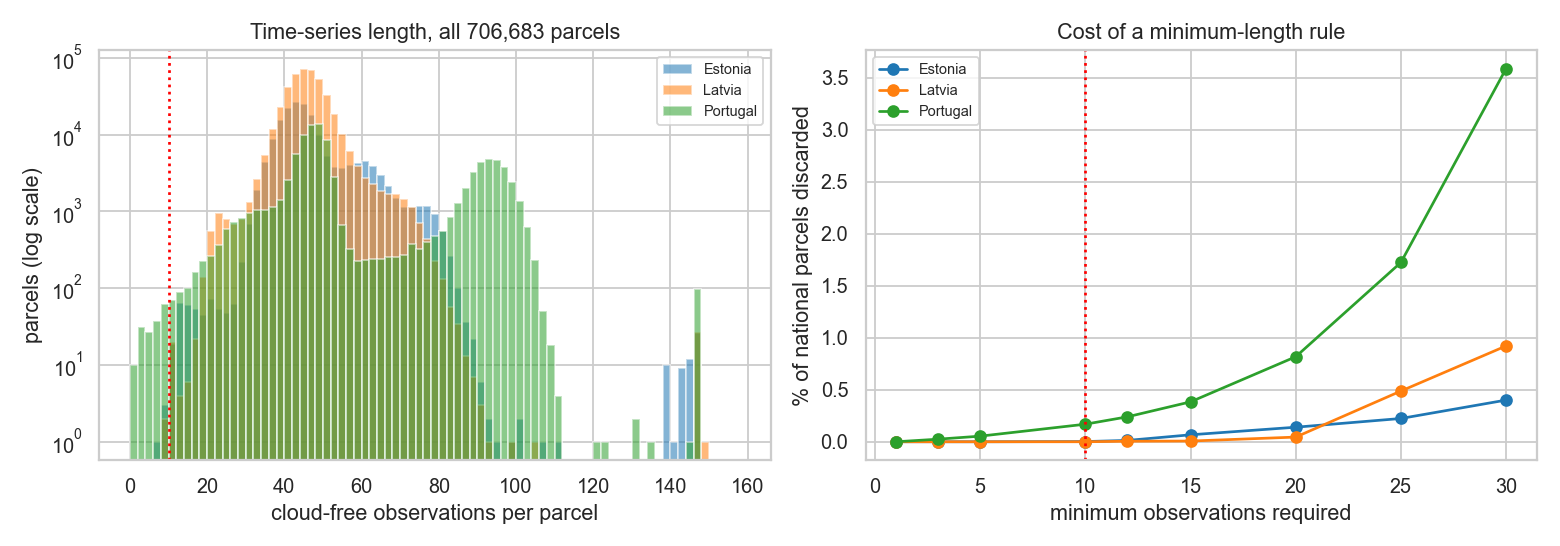

In [14]:
ts_rule = pd.DataFrame(cd["timestep_threshold_loss"])
table(ts_rule)
print(json.dumps(cd["timestep_stats"], indent=2))
show("13_timeseries_length_rule.png", width=980)

### 4.3 What needs to be cut off? Minimum time-series length

A minimum-length rule is almost free. Requiring at least 10 cloud-free observations discards 174 parcels in total, which is 0.025 % of the dataset; 168 of them are Portuguese, 4 Estonian and 2 Latvian. Raising the bar to 20 observations still costs only 1,254 parcels (0.18 %), and to 30 observations 8,255 parcels (1.17 %), at which point Portugal alone loses 3.6 %.

**Recommendation: require at least 10 observations.** It removes the pathological parcels, including the Portuguese parcels with a single acquisition that the proposal-phase analysis flagged, at negligible cost, and it leaves every parcel with enough temporal support for a phenological feature extractor to produce something meaningful. A stricter rule of 20 is defensible if the TIMESAT phenometrics baseline turns out to be unstable at low observation counts, and it would still cost under a fifth of one per cent, so this should be revisited once the baseline is implemented rather than decided now.

In [15]:
print(json.dumps(cd["geometry"], indent=2))
print("\nidentifier and geometry integrity:")
print(json.dumps(cd["integrity"], indent=2))

{
  "Estonia": {
    "n": 175906,
    "n_outside_bbox": 0,
    "pct_outside_bbox": 0.0,
    "n_missing_coords": 0,
    "lon_min": 21.7797,
    "lon_max": 28.1557,
    "lat_min": 57.5178,
    "lat_max": 59.645
  },
  "Latvia": {
    "n": 431143,
    "n_outside_bbox": 0,
    "pct_outside_bbox": 0.0,
    "n_missing_coords": 0,
    "lon_min": 20.9844,
    "lon_max": 28.2142,
    "lat_min": 55.6758,
    "lat_max": 58.072
  },
  "Portugal": {
    "n": 99634,
    "n_outside_bbox": 0,
    "pct_outside_bbox": 0.0,
    "n_missing_coords": 0,
    "lon_min": -9.4531,
    "lon_max": -6.468,
    "lat_min": 37.3216,
    "lat_max": 42.1374,
    "n_outside_mainland": 0,
    "pct_outside_mainland": 0.0
  }
}

identifier and geometry integrity:
{
  "n_rows_sharing_a_coordinate": 2,
  "n_unique_coordinates": 706682,
  "n_rows_duplicate_parcel_id_global": 0,
  "n_rows_duplicate_parcel_id_within_country": 0,
  "n_rows_duplicate_nuts_parcel_id": 0,
  "n_parcel_ids_in_multiple_nuts": 0,
  "n_parcels_zero_time

### 4.4 What needs to be cut off? Suspect geometry and duplicates

The dataset is clean on every check that was run over all 706,683 parcels.

No parcel has a missing coordinate, and no parcel falls outside its national bounding box. The Portuguese centroids span 9.45 to 6.47 degrees west and 37.3 to 42.1 degrees north, so all Portuguese parcels are on the mainland and neither the Azores nor Madeira appear.

The parcel identifier is globally unique. There are zero duplicated identifiers across the whole dataset, zero within a country, zero for the NUTS and identifier pair, and zero identifiers appearing in more than one NUTS region. No parcel has a zero-length time series. Exactly two rows share an identical centroid, and those two belong to the same class in the same country, so they are almost certainly two adjacent sub-parcels of one field rather than a data error.

**Recommendation: no geometric or identifier exclusions are required.** The bounding-box check should nonetheless stay in the pipeline as an assertion, because it is cheap and it would catch a corrupted rebuild. The one operational consequence is positive: because `parcel_id` is globally unique, it can be used directly as the split key with no risk of leakage across folds.

,threshold,implied_k_max,n_classes_estonia,n_classes_latvia,n_classes_portugal,n_classes_all_three,shared_ES_LA,shared_ES_PO,shared_LA_PO,pct_parcels_kept_portugal
0,20,0,58,74,34,12,43,15,17,99.64
1,50,0,44,57,30,9,31,11,13,99.44
2,100,0,31,49,22,8,25,9,11,98.42
3,200,25,29,37,19,7,23,8,7,97.56
4,250,50,28,34,18,7,22,8,7,97.15
5,300,75,26,31,15,6,20,7,6,95.84
6,350,100,25,30,12,5,19,6,5,94.18
7,500,175,23,26,10,5,18,5,5,92.76
8,550,200,21,25,9,4,17,4,4,91.91
9,1000,425,17,20,7,1,14,2,2,89.48



minimum class size implied by each budget, as 2*K + validation(50) + test(100):
{
  "1": 152,
  "5": 160,
  "10": 170,
  "20": 190,
  "50": 250,
  "100": 350,
  "200": 550
}


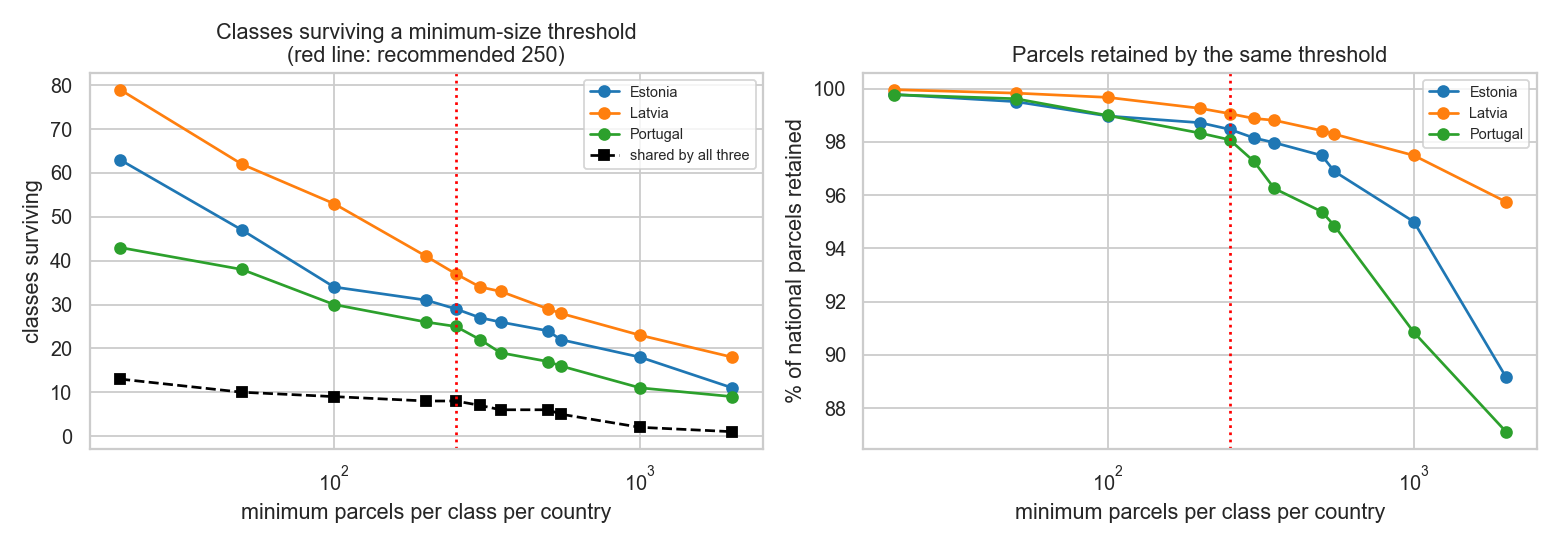

In [16]:
surv = cached(CACHE / "retained_class_survival.parquet", "_class_design.py")
cols = ["threshold", "implied_k_max", "n_classes_estonia", "n_classes_latvia",
        "n_classes_portugal", "n_classes_all_three", "shared_ES_LA", "shared_ES_PO",
        "shared_LA_PO", "pct_parcels_kept_portugal"]
table(surv[cols])
print("\nminimum class size implied by each budget, "
      "as 2*K + validation(50) + test(100):")
print(json.dumps(cd["min_class_size_for_K"], indent=2))
show("12_class_size_survival.png", width=980)

### 4.5 What needs to be cut off? Minimum class size

The floor follows from the protocol rather than from taste. A class must supply, simultaneously, a held-out test set that stays fixed across every label budget, a validation set for head selection, and a training pool from which the K training parcels are drawn afresh at each of the five random draws.

Taking a test set of at least 100 parcels per class (which keeps the standard error of a per-class recall near 0.8 at about 0.04), a validation set of at least 50, and a training pool of at least twice the largest budget so that the five draws are not near-identical subsets, the minimum class size is

    min_class_size = 2 * K_max + 50 + 100

which gives 250 parcels for K_max = 50, 350 for K_max = 100 and 550 for K_max = 200.

The table above evaluates each candidate threshold **after** the catch-all, forestry, minimum-length and bounding-box filters, so it is the operational count rather than the raw count. The pattern is clear: Estonia and Latvia are insensitive over this range, while Portugal collapses. At a threshold of 250 Portugal retains 18 classes; at 350 it retains 12; at 550 it retains 9. The three-way intersection falls from 7 classes to 5 to 4 over the same range.

**Recommendation: set the minimum class size to 250 parcels per class per country, which caps the label-budget grid at K_max = 50.** This is the largest budget Portugal can support while still yielding a class set in the 15 to 20 range that the proposal targets. The grid then becomes K in {1, 5, 10, 20, 50}, which still spans a factor of fifty and covers the region where the answer to RQ1 actually lies, since the interesting question is where a foundation model stops beating a raw-feature baseline, not what happens once labels are plentiful. If K = 100 and K = 200 are wanted for the Baltic pair specifically, they can be run for Estonia and Latvia only, where a threshold of 550 still leaves 21 and 25 classes respectively, and reported as a clearly labelled extension.

**This contradicts the proposal in two places and both should be corrected.** First, the proposal's methods section defines K as a percentage grid of {1, 5, 10, 20, 50, 100} % of the available training labels while its work-plan table defines K as {1, 5, 10, 20, 50, 100, 200} samples per class. The percentage definition cannot be used here: 1 % of Latvian grassland is 2,150 parcels while 1 % of Portuguese potatoes is 5, so a percentage grid would make the label budget a different experiment in every class and would confound label scarcity with class frequency. K must be an absolute number of parcels per class. Second, the absolute grid should stop at 50 rather than 200, because 200 is not supportable in Portugal without reducing the Portuguese class set below the target size.

,level,n_classes,gini,normalised_entropy,max_class_share_pct,shared_all_three_min0,shared_all_three_min350,n_classes_estonia_min350,n_classes_latvia_min350,n_classes_portugal_min350
0,3,6,0.5955,0.5870,44.65,5,3,3,3,5
1,4,47,0.8790,0.4914,44.65,24,7,13,17,16
2,5,133,0.9247,0.4745,44.65,38,6,20,30,19
3,6,176,0.9284,0.4805,44.65,35,6,26,33,19


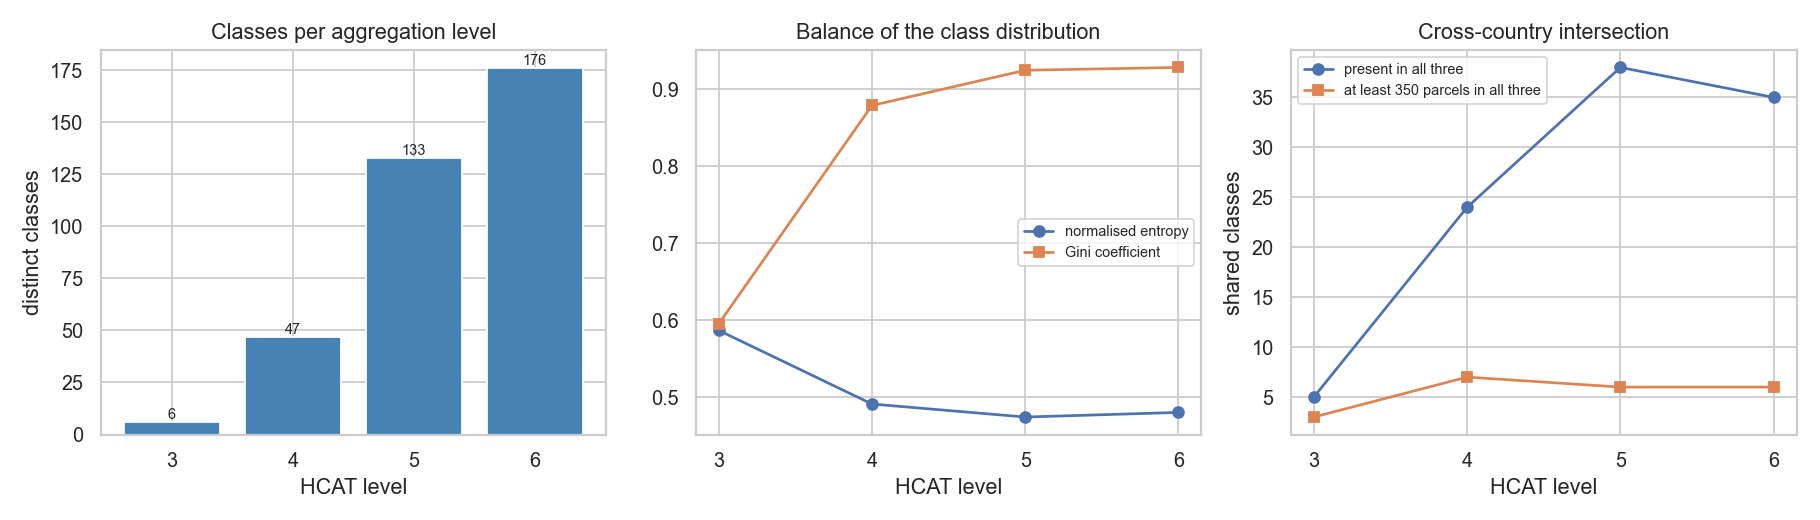

In [17]:
agg = cached(CACHE / "aggregation_levels.parquet", "_class_design.py")
table(agg[["level", "n_classes", "gini", "normalised_entropy", "max_class_share_pct",
           "shared_all_three_min0", "shared_all_three_min350",
           "n_classes_estonia_min350", "n_classes_latvia_min350",
           "n_classes_portugal_min350"]])
show("14_aggregation_levels.png", width=980)

In [18]:
print("class counts and intersections at HCAT level 4, after the same filters:")
table(surv[["threshold", "implied_k_max", "n_classes_level4_estonia",
            "n_classes_level4_latvia", "n_classes_level4_portugal",
            "n_classes_all_three_level4", "shared_level4_ES_PO", "shared_level4_LA_PO"]])

class counts and intersections at HCAT level 4, after the same filters:


,threshold,implied_k_max,n_classes_level4_estonia,n_classes_level4_latvia,n_classes_level4_portugal,n_classes_all_three_level4,shared_level4_ES_PO,shared_level4_LA_PO
0,20,0,21,25,19,14,14,15
1,50,0,17,20,15,9,9,10
2,100,0,15,18,12,8,8,8
3,200,25,13,17,12,7,7,8
4,250,50,12,16,12,7,7,8
5,300,75,12,15,9,6,6,6
6,350,100,12,15,9,6,6,6
7,500,175,11,14,9,6,6,6
8,550,200,11,13,8,5,5,5
9,1000,425,10,9,8,4,5,4


### 4.6 What aggregation would be important?

Rolling the HCAT codes up the hierarchy gives 6 classes at level 3, 47 at level 4, 133 at level 5 and 176 at the native depth. The Gini coefficient of the class-size distribution falls from 0.928 at level 6 to 0.879 at level 4 and 0.596 at level 3, so aggregation does buy balance, but the largest class remains grassland at 44.6 % at every level from 3 downwards, because grassland is itself a level-3 node and cannot be merged into anything.

The decisive comparison is what aggregation buys the cross-country experiment against what it costs in-country. At a threshold of 250 parcels, the native resolution gives 28, 34 and 18 classes for Estonia, Latvia and Portugal with a three-way intersection of 7 classes. Level 4 gives 12, 16 and 12 classes with a three-way intersection of 7. Aggregation therefore buys **nothing at all** for the size of the three-way intersection while roughly halving the in-country class sets.

What it does buy is the **quality** of the shared classes rather than their number. At the native resolution, the classes that Portugal shares with the Baltics are oats (933 Portuguese parcels), potatoes (523), rye (280) and grain maize. At level 4 the same intersection becomes cereal (6,337 Portuguese parcels), plants harvested green (4,563), legumes (288), potatoes (523), orchards and fruits (1,726) and fresh vegetables (1,971). The Portuguese side of the transfer experiment goes from a handful of marginal classes to several that comfortably clear the size threshold.

**Recommendation.**

1. **In-country: keep the native HCAT resolution, with no roll-up.** Aggregation costs roughly half the class set and buys no extra shared classes, and the in-country task is where the fine distinctions are the point.
2. **Cross-country: run the transfer experiment twice, once at the native resolution on the strict intersection and once at level 4.** The level-4 run is the one that will produce interpretable Portuguese numbers; the native run is the honest one and should be reported alongside it. The configuration file carries both class lists.
3. **Keep the winter and spring variants separate.** This is agronomically the more interesting test, because winter and spring soft wheat are the same species and differ only in sowing date and therefore in phenology, so distinguishing them is a pure test of whether the encoder represents temporal structure rather than spectral signature. Merging them would remove the single most diagnostic pair in the dataset.

,parent_name,winter_code,winter_n_total,winter_n_estonia,winter_n_latvia,spring_code,spring_n_total,spring_n_estonia,spring_n_latvia,merged_n_total
0,common soft wheat,3301010101,64325,13722,50603,3301010102,27046,5522,21524,91371
1,barley,3301010401,3813,2245,1568,3301010402,23670,10736,12934,27483
2,rapeseed rape,3301060401,17847,6011,11836,3301060402,1236,1236,0,19083
3,triticale,3301010801,1842,533,1309,3301010802,333,195,138,2175
4,spelt,3301011001,130,0,130,3301011002,15,0,15,145


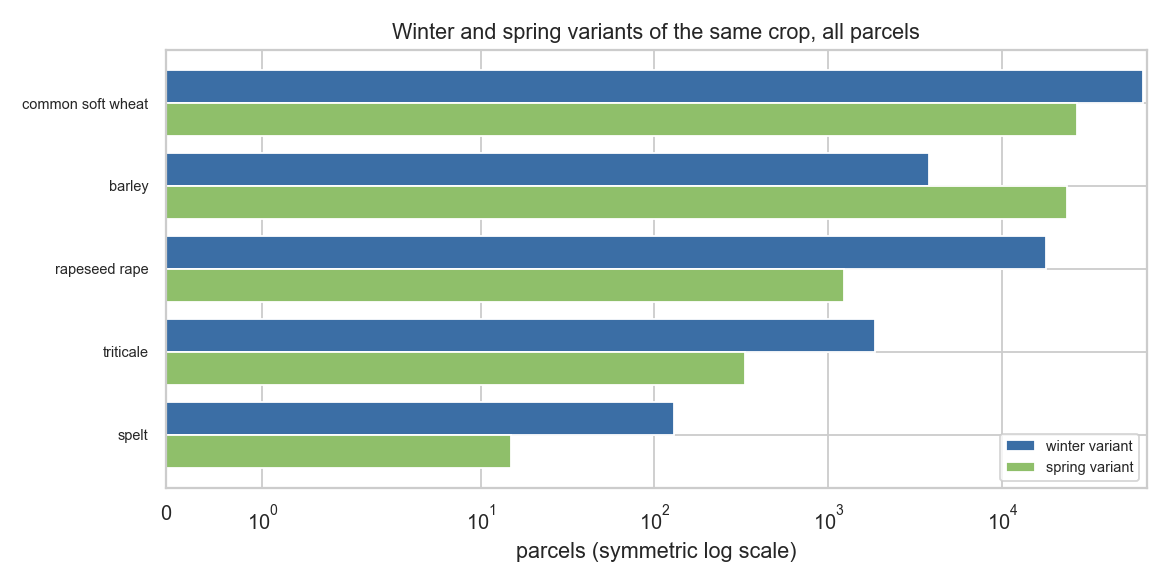

In [19]:
pairs = pd.DataFrame(cd["seasonal_pairs"])
table(pairs[["parent_name", "winter_code", "winter_n_total", "winter_n_estonia",
             "winter_n_latvia", "spring_code", "spring_n_total", "spring_n_estonia",
             "spring_n_latvia", "merged_n_total"]])
show("15_seasonal_variants.png", width=760)

Five crops appear in both a winter and a spring variant: common soft wheat (64,325 winter against 27,046 spring), barley (3,813 against 23,670), rapeseed (17,847 against 1,236), triticale (1,842 against 333) and spelt (130 against 15). Every one of these pairs has **zero parcels in Portugal**, so the winter and spring distinction is purely a Baltic phenomenon and is relevant to the in-country tasks and to the Estonia to Latvia transfer, but is irrelevant to any pair involving Portugal. Wheat, barley and rapeseed all clear the 250-parcel threshold in both variants in at least one country and should be kept separate.

In [20]:
print("recommended operating point:")
print(json.dumps(cd["recommended"], indent=2))
print("\nparcels surviving all filters: "
      f"{cd['n_parcels_after_filters']:,} of {cd['n_parcels']:,} "
      f"({cd['pct_parcels_after_filters']} %)")
print("per country:", cd["parcels_after_filters_per_country"])
print("\nclasses at or above 250 parcels:", cd["retained_classes_per_country_before_cap"])
print("after capping at the", cd["max_classes_per_country"],
      "most frequent per country:", cd["retained_classes_per_country"])
print("share of each country's filtered parcels covered by the retained classes:",
      cd["retained_coverage_pct"])

recommended operating point:
{
  "min_class_size_per_country": 250,
  "K_max": 50,
  "max_classes_per_country": 20,
  "min_timesteps": 10,
  "aggregation": "native HCAT level, no roll-up, for the in-country task",
  "rationale_min_class_size": "2 * K_max(50) + validation(50) + test(100)"
}

parcels surviving all filters: 627,897 of 706,683 (88.85 %)
per country: {'Estonia': 173549, 'Latvia': 393107, 'Portugal': 61241}

classes at or above 250 parcels: {'Estonia': 28, 'Latvia': 34, 'Portugal': 18}
after capping at the 20 most frequent per country: {'Estonia': 20, 'Latvia': 20, 'Portugal': 18}
share of each country's filtered parcels covered by the retained classes: {'Estonia': 96.63, 'Latvia': 97.32, 'Portugal': 97.15}


**Estonia: 20 classes**

,hcat,crop_name,n
0,3302000000,pasture meadow grassland grass,84054
1,3301010101,winter common soft wheat,13722
2,3301090300,legumes harvested green,13144
3,3301010402,spring barley,10736
4,3301010500,oats,6911
5,3301090303,clover,6875
6,3301060401,winter rapeseed rape,6011
7,3301010102,spring common soft wheat,5522
8,3301020600,peas,4209
9,3301030000,potatoes,3423


**Latvia: 20 classes**

,hcat,crop_name,n
0,3302000000,pasture meadow grassland grass,215020
1,3301010101,winter common soft wheat,50603
2,3301010500,oats,22792
3,3301010102,spring common soft wheat,21524
4,3301010402,spring barley,12934
5,3301060401,winter rapeseed rape,11836
6,3301030000,potatoes,8653
7,3301090303,clover,6461
8,3301010300,rye,6357
9,3301150200,buckwheat,4470


**Portugal: 18 classes**

,hcat,crop_name,n
0,3303050000,olive plantations,18683
1,3302000000,pasture meadow grassland grass,16434
2,3303060000,vineyards wine vine rebland grapes,5329
3,3301010600,grain maize corn popcorn,4471
4,3301090100,temporary grass,4207
5,3303030500,sweet chestnuts,3701
6,3301070000,fresh vegetables,1971
7,3301010500,oats,933
8,3303011200,pears,558
9,3301030000,potatoes,523


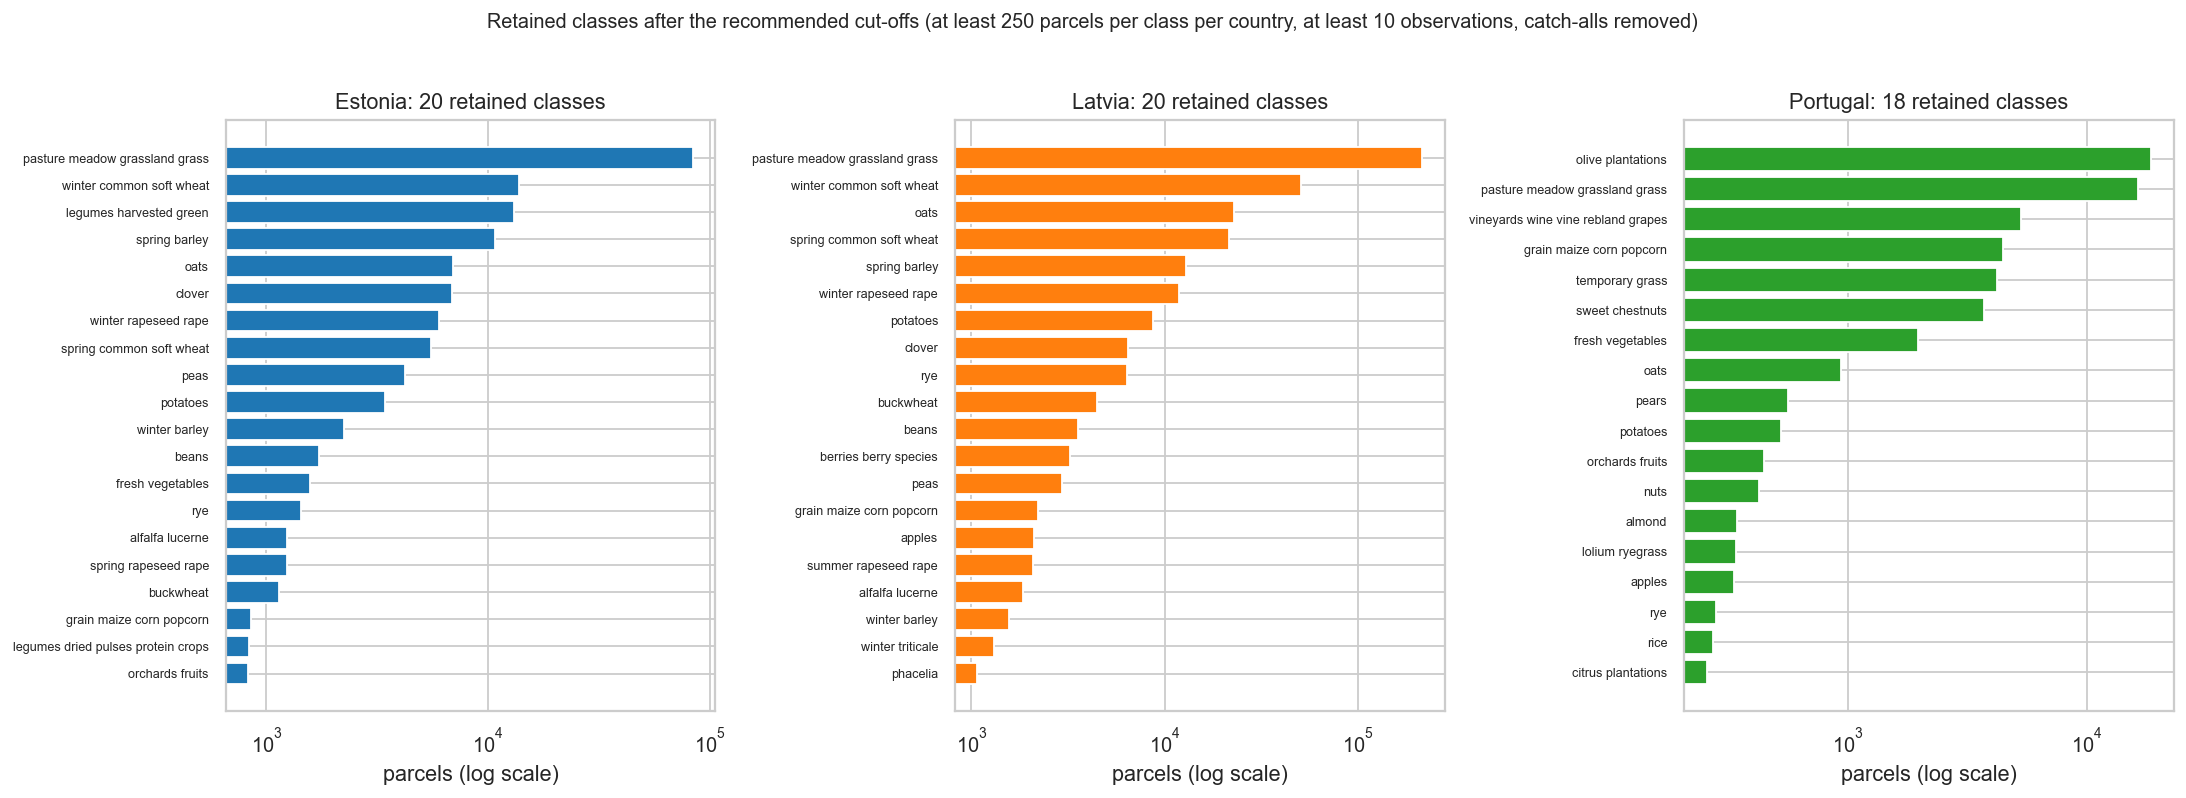

In [21]:
retained = cached(CACHE / "retained_classes.parquet", "_class_design.py")
for c in ["Estonia", "Latvia", "Portugal"]:
    sub = retained[retained.country == c].reset_index(drop=True)
    display(Markdown(f"**{c}: {len(sub)} classes**"))
    table(sub[["hcat", "crop_name", "n"]])
show("16_retained_classes.png", width=1000)

### 4.7 The proposed class scheme

Applying the recommended rules, that is removing the catch-all and forestry codes, requiring at least 10 observations, requiring the centroid to fall inside the national bounding box, and requiring at least 250 parcels per class per country, leaves 627,897 parcels, or 88.9 % of the dataset: 173,549 in Estonia, 393,107 in Latvia and 61,241 in Portugal. Portugal loses 38.5 % of its parcels, almost all of that to HCAT 3399000000 alone.

Twenty-eight Estonian, thirty-four Latvian and eighteen Portuguese classes clear the threshold. Capping the reporting set at the twenty most frequent per country gives the final in-country lists of **20, 20 and 18 classes**, which covers 96.6 %, 97.3 % and 97.2 % of each country's filtered parcels respectively. This sits inside the 15 to 20 range the proposal targets, and it was reached by asking what the data supports rather than by forcing the number.

In [22]:
print("three-way intersection at the native resolution:", len(cd["shared_three_way"]))
table(pd.DataFrame(cd["shared_three_way"]))
print("\npairwise intersections at the native resolution:")
print(json.dumps(cd["shared_pairwise_counts"], indent=2))
for k, v in cd["shared_pairwise"].items():
    print(f"  {k}: " + ", ".join(r["crop_name"] for r in v))

three-way intersection at the native resolution: 5


,hcat,crop_name,estonia,latvia,portugal
0,3302000000,pasture meadow grassland grass,84054,215020,16434
1,3301010500,oats,6911,22792,933
2,3301030000,potatoes,3423,8653,523
3,3301010300,rye,1427,6357,280
4,3301010600,grain maize corn popcorn,852,2215,4471



pairwise intersections at the native resolution:
{
  "Estonia|Latvia": 15,
  "Estonia|Portugal": 7,
  "Latvia|Portugal": 6
}
  Estonia|Latvia: pasture meadow grassland grass, winter common soft wheat, spring barley, oats, clover, winter rapeseed rape, spring common soft wheat, peas, potatoes, winter barley, beans, rye, alfalfa lucerne, buckwheat, grain maize corn popcorn
  Estonia|Portugal: pasture meadow grassland grass, oats, potatoes, fresh vegetables, rye, grain maize corn popcorn, orchards fruits
  Latvia|Portugal: pasture meadow grassland grass, oats, potatoes, rye, grain maize corn popcorn, apples


In [23]:
print("three-way intersection at HCAT level 4:", len(cd["level4_shared_three_way"]))
table(pd.DataFrame(cd["level4_shared_three_way"]))
print("\npairwise intersections at level 4:")
print(json.dumps(cd["level4_shared_pairwise_counts"], indent=2))
print("\nretained classes per country at level 4:", cd["level4_retained_per_country"])

three-way intersection at HCAT level 4: 7


,hcat,crop_name,estonia,latvia,portugal
0,3302000000,pasture meadow grassland grass,84054,215020,16434
1,3301010000,cereal,42219,119617,6337
2,3301090000,plants harvested green,21798,9017,4563
3,3301020000,legumes dried pulses protein crops,6762,6581,288
4,3301030000,potatoes,3423,8653,523
5,3303010000,orchards fruits,1282,2965,1726
6,3301070000,fresh vegetables,1569,833,1971



pairwise intersections at level 4:
{
  "Estonia|Latvia": 12,
  "Estonia|Portugal": 7,
  "Latvia|Portugal": 8
}

retained classes per country at level 4: {'Estonia': 12, 'Latvia': 16, 'Portugal': 12}


### 4.8 The cross-country class lists

At the native resolution, and computed on the capped in-country lists, the intersections are 15 classes for Estonia and Latvia, 7 for Estonia and Portugal, 6 for Latvia and Portugal, and **5 for the three-way intersection**: grassland, oats, potatoes, rye and grain maize. Computed on the uncapped lists (every class with at least 250 parcels) the same intersections are 22, 8, 7 and 7.

At HCAT level 4 the intersections are 12, 7 and 8 for the pairs and **7 for the three-way intersection**: grassland, cereal, plants harvested green, legumes and protein crops, potatoes, orchards and fruits, and fresh vegetables. The Portuguese counts on this list are far healthier, which is why the level-4 run should be reported as the primary cross-country result with the native run alongside it.

**The Estonia to Latvia pair is a genuinely different experiment from anything involving Portugal.** It has 15 shared classes at the native resolution, including the winter and spring pairs, and both countries have the same climate, the same phenological calendar and largely the same crops, so it tests generalisation across administrative and management differences. The pairs involving Portugal have 6 or 7 shared classes, a twenty-degree latitudinal gap and qualitatively different phenology within the shared classes. These should be presented as two distinct transfer regimes rather than as points on one scale.

The complete scheme, with the HCAT code to crop name to thesis class mapping, the exclusion lists, the protocol parameters and both sets of cross-country lists, is written to `configs/class_scheme_eurocropsml.yaml` for Phase 1 code to consume directly.

In [24]:
scheme_path = REPO / "configs" / "class_scheme_eurocropsml.yaml"
print(scheme_path.relative_to(REPO), "exists:", scheme_path.exists(),
      f"({scheme_path.stat().st_size:,} bytes)")
print("\n".join(scheme_path.read_text(encoding="utf-8").splitlines()[:46]))
print("...")

configs\class_scheme_eurocropsml.yaml exists: True (13,858 bytes)
name: eurocropsml_thesis_class_scheme
version: 1
generated_by: results/eda/_class_design.py
source:
  catalogue: data/catalogue_parcels_full.parquet
  n_parcels_scanned: 706683
  is_full_dataset: true
  hcat_version: HCAT2, EuroCrops (maja601/EuroCrops, hcat_core/HCAT2.csv)
random_seed: 42
protocol:
  K_grid_samples_per_class:
  - 1
  - 5
  - 10
  - 20
  - 50
  K_grid_extended_estonia_latvia_only:
  - 100
  - 200
  K_definition: absolute number of labelled parcels per class, never a percentage
    of the available labels
  n_draws_per_K: 5
  n_test_min_per_class: 100
  n_val_min_per_class: 50
  train_pool_multiplier: 2
  K_max_supported: 50
aggregation:
  in_country: native HCAT level as published, no roll-up
  seasonal_variants: kept separate; winter and spring variants of the same species
    differ in phenology rather than in species, which is the discriminative signal
    the benchmark is meant to test
  cross_countr

## 5. What a Phase 1 benchmark additionally needs

The sections above answer the class-design questions. This section covers the statistics a Phase 1 protocol needs that the proposal-phase analysis did not provide: the spatial structure that spatial block cross-validation depends on, the temporal sampling that the monthly-grid baseline depends on, and a sanity check that the retained classes are separable at all.

,country,radius_km,mean_same_class_fraction_in_ring,background_prior,excess_over_baseline,median_neighbours_cumulative,n_query_points,n_reference_parcels
0,Estonia,0.25,0.5281,0.2566,0.2715,1.0,2500,120000
1,Estonia,0.50,0.4211,0.2566,0.1644,5.0,2500,120000
2,Estonia,1.00,0.3436,0.2566,0.0870,17.0,2500,120000
3,Estonia,2.00,0.3098,0.2566,0.0531,56.0,2500,120000
4,Estonia,5.00,0.2955,0.2566,0.0389,284.0,2500,120000
5,Estonia,10.00,0.2841,0.2566,0.0274,972.0,2500,120000
6,Estonia,20.00,0.2738,0.2566,0.0172,3432.5,2500,120000
7,Estonia,50.00,0.2648,0.2566,0.0081,17453.0,2500,120000
9,Latvia,0.25,0.5228,0.3244,0.1984,1.0,2500,120000
10,Latvia,0.50,0.4647,0.3244,0.1403,3.0,2500,120000



median distance to the nearest neighbouring parcel, km: {'Estonia': 0.1807, 'Latvia': 0.223, 'Portugal': 0.1646}


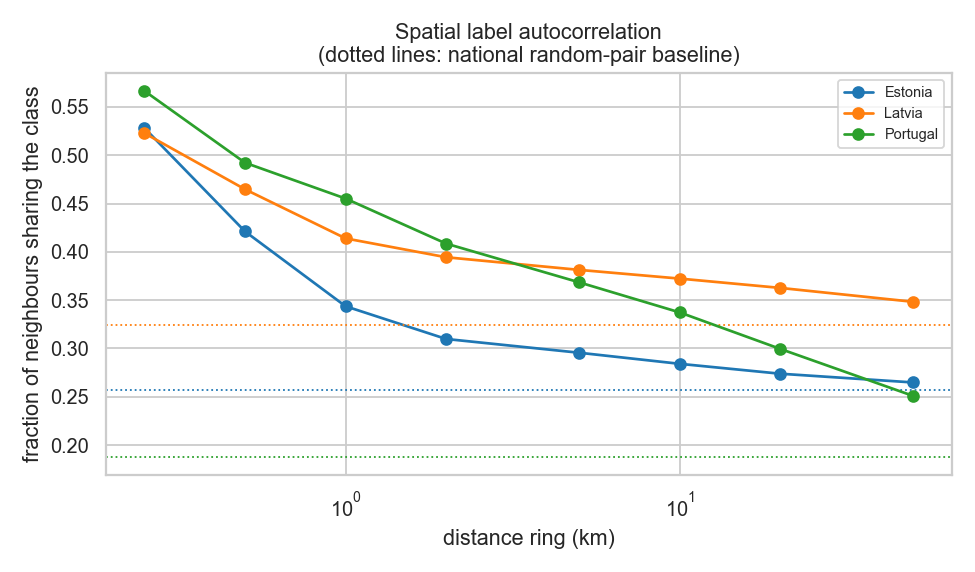

In [25]:
spatial = cached(CACHE / "spatial_stats.parquet", "_class_design.py")
rings = spatial.dropna(subset=["radius_km"]).copy()
rings["excess_over_baseline"] = (rings["mean_same_class_fraction_in_ring"]
                                 - rings["background_prior"])
table(rings[["country", "radius_km", "mean_same_class_fraction_in_ring",
             "background_prior", "excess_over_baseline",
             "median_neighbours_cumulative", "n_query_points",
             "n_reference_parcels"]].round(4))
print("\nmedian distance to the nearest neighbouring parcel, km:",
      cd["median_nn_distance_km"])
show("17_spatial_autocorrelation.png", width=680)

### 5.1 Spatial structure

Parcels are dense. The median distance from a parcel to its nearest neighbour is 181 m in Estonia, 223 m in Latvia and 165 m in Portugal, and within 1 km of a given parcel there are typically 17 other parcels in Estonia, 11 in Latvia and 12 in Portugal, rising to roughly 970, 650 and 550 within 10 km.

Labels are strongly autocorrelated at short range. Within 250 m of a parcel, 52.8 % of its neighbours share its class in Estonia, 52.3 % in Latvia and 56.7 % in Portugal, against random-pair baselines of 25.7 %, 32.4 % and 18.8 %. The excess over the baseline is therefore +0.27, +0.20 and +0.38 at 250 m. It halves by about 1 km, and by 20 km it has fallen to +0.017 in Estonia and +0.038 in Latvia, that is to between 6 % and 19 % of its short-range value. Portugal is different: the excess is still +0.111 at 20 km and +0.063 at 50 km, because Portuguese crops are regionally specialised (olives in the interior south, vineyards in the Douro), so a large part of the Portuguese autocorrelation is genuine environmental stratification rather than field-level nuisance correlation that blocking can remove.

These statistics were computed from a seeded sample of up to 120,000 reference parcels and 2,500 query points per country, drawn from the filtered catalogue; the exact figures are recorded in `results/eda/cache/spatial_stats.parquet`.

,country,block_km,n_blocks,median_parcels_per_block,p90_parcels_per_block,min_blocks_per_class,median_blocks_per_class,n_classes_with_ge_5_blocks,n_classes_with_ge_10_blocks,n_retained_classes
0,Estonia,1,26466,5.0,13.0,565,2006.5,20,20,20
1,Estonia,2,8901,16.0,39.0,434,1483.0,20,20,20
2,Estonia,5,1832,83.0,186.0,270,811.0,20,20,20
3,Estonia,10,532,277.0,637.6,154,358.0,20,20,20
4,Estonia,20,153,1080.0,2031.6,79,119.0,20,20,20
5,Estonia,50,35,4260.0,9798.8,24,29.0,20,20,20
6,Estonia,100,14,6507.0,27376.5,8,11.0,20,18,20
7,Latvia,1,44976,7.0,18.0,786,2747.5,20,20,20
8,Latvia,2,13963,22.0,57.0,716,2198.0,20,20,20
9,Latvia,5,2659,128.0,283.0,476,1175.5,20,20,20


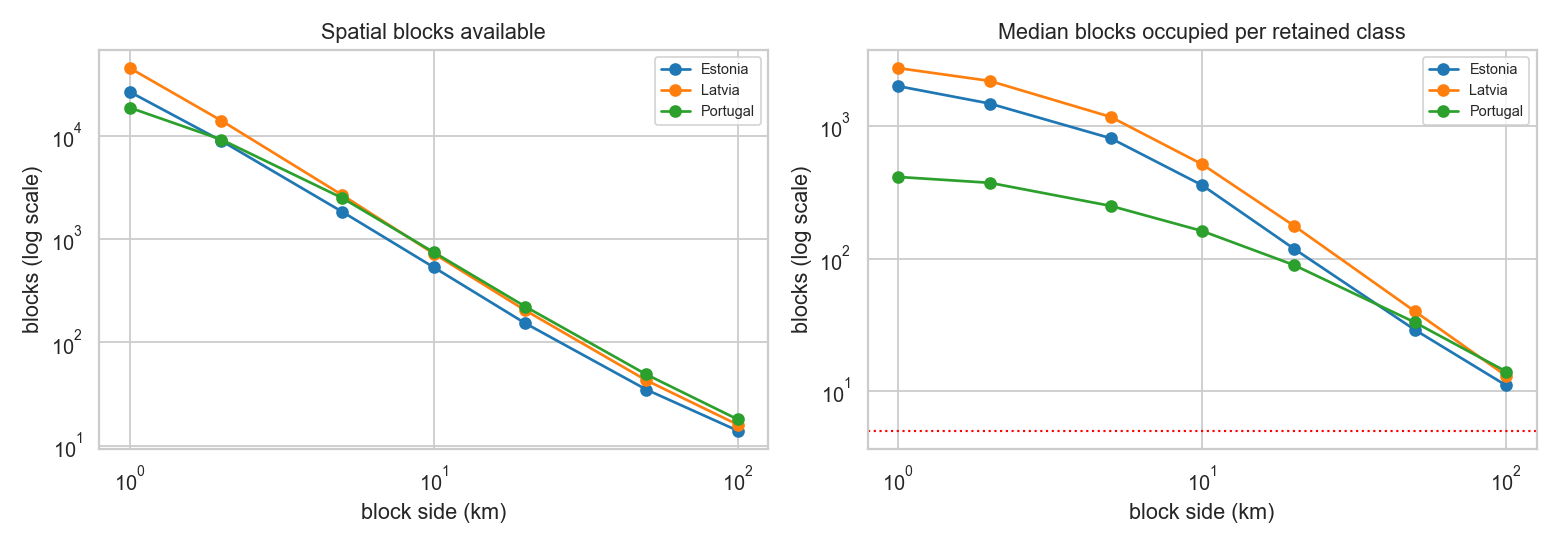

In [26]:
blocks = cached(CACHE / "block_occupancy.parquet", "_class_design.py")
table(blocks)
show("18_block_occupancy.png", width=980)

### 5.2 A starting recommendation for the spatial block size

This is deliberately descriptive. The full cross-region protocol is being designed separately; what follows is the evidence that design needs plus one defensible default.

The requirement is a block large enough that the label autocorrelation between a training block and a test block is small, and small enough that every retained class still occupies enough distinct blocks to form at least five folds.

**A block side of 20 km satisfies both.** At 20 km the excess same-class fraction has decayed to roughly a tenth of its short-range value in Estonia and a fifth in Latvia, and the grid yields 153 blocks in Estonia, 204 in Latvia and 222 in Portugal. Every retained class occupies at least 79 distinct blocks in Estonia, at least 138 in Latvia and at least 18 in Portugal, so five-fold or ten-fold spatial block cross-validation is comfortably supported everywhere, with Portugal as the binding case. A 50 km block would reduce Portugal's rarest class to 8 blocks, which is the point at which five folds begin to be unbalanced, and a 10 km block leaves a residual excess of +0.027 and +0.048 in Estonia and Latvia respectively, which is tolerable but less conservative.

**Recommendation: 20 km square blocks as the default, with 10 km reported as a sensitivity check.** Portugal's residual long-range structure should be handled by the cross-region design rather than by inflating the block size, because it reflects real regional specialisation and cannot be blocked away without exhausting the country.

**Percentage of filtered parcels with at least one observation in each month**

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Estonia,6.98,37.71,78.07,99.67,99.92,99.99,99.99,93.22,99.94,99.99,86.47,10.16
Latvia,2.41,27.44,96.27,99.70,99.91,99.98,99.99,94.27,99.99,100.00,98.48,24.28
Portugal,98.76,99.92,99.79,98.23,98.26,96.10,92.94,92.21,99.28,99.52,99.90,97.39


**Mean number of observations per parcel in each month**

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Estonia,0.08,0.43,1.80,5.33,5.67,8.92,7.98,3.24,4.97,5.98,2.15,0.12
Latvia,0.03,0.28,2.63,4.34,5.16,7.68,8.33,3.08,5.54,5.79,2.62,0.28
Portugal,3.61,3.66,5.87,3.69,5.37,5.05,5.91,5.70,4.82,5.71,6.56,3.71


completeness of a twelve-month grid, %: {'Estonia': 76.01, 'Latvia': 78.56, 'Portugal': 97.69}
completeness restricted to March to October, %: {'Estonia': 96.35, 'Latvia': 98.76, 'Portugal': 97.04}


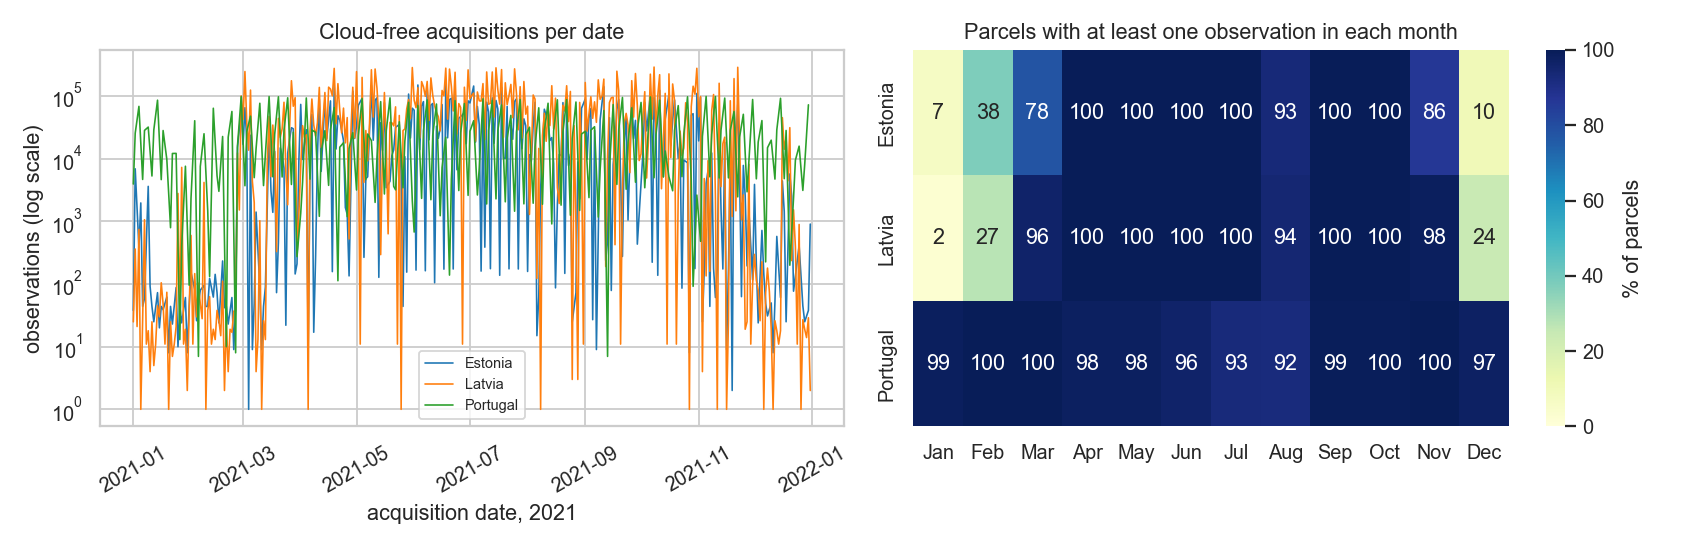

In [27]:
monthly = pd.DataFrame(cd["monthly_coverage_pct_parcels_with_obs"]).T
monthly.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                   "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
display(Markdown("**Percentage of filtered parcels with at least one observation in each month**"))
table(monthly)
mean_obs = pd.DataFrame(cd["monthly_mean_observations"]).T
mean_obs.columns = monthly.columns
display(Markdown("**Mean number of observations per parcel in each month**"))
table(mean_obs)
print("completeness of a twelve-month grid, %:", cd["monthly_grid_completeness_pct"])
print("completeness restricted to March to October, %:",
      cd["growing_season_grid_completeness_mar_oct_pct"])
show("19_temporal_sampling.png", width=1000)

### 5.3 Temporal sampling and the monthly-grid baseline

The acquisition-date histogram shows the two regimes plainly. In Estonia and Latvia the cloud-free record collapses in winter: only 7.0 % of Estonian parcels and 2.4 % of Latvian parcels have any observation at all in January, and 37.7 % and 27.4 % in February. From April to October coverage is essentially complete, the one dip being August (93.2 % and 94.3 %), which is a cloudy month in the Baltics in 2021. Portugal has no such collapse; at least 92 % of Portuguese parcels are observed in every single month of the year, and the mean observation count is nearly flat across the calendar.

This matters directly for one of the two raw-feature baselines. A fixed monthly-grid resample over all twelve months would be only **76.0 % complete for Estonia and 78.6 % for Latvia**, against 97.7 % for Portugal, so roughly a quarter of the Baltic cells would be empty and would have to be imputed. Restricting the same grid to **March to October** raises completeness to 96.4 % for Estonia, 98.8 % for Latvia and 97.0 % for Portugal.

**Recommendation: define the monthly-grid baseline over March to October, that is eight bins rather than twelve.** This gives a nearly complete feature matrix in all three countries, it removes the need for heavy winter imputation that would otherwise inject a systematic country effect into the baseline, and it loses almost nothing, because the Baltic winter cells carry no information anyway. Whatever is decided, the imputation rule and the number of empty cells per country must be reported, because an imputed cell is not a measurement and a baseline that silently imputes a quarter of its features is not comparable across countries.

There is a second consequence, for AlphaEarth. Its embeddings are annual, and in the Baltics the underlying observations are concentrated in May to September, so an annual AlphaEarth embedding for an Estonian or Latvian parcel is effectively a growing-season composite rather than a true annual statistic. The proposal already anticipates this; the numbers above quantify it and should be cited when the AlphaEarth results are reported.

phenology sampling: {
  "script": "results/eda/_phenology.py",
  "random_seed": 42,
  "parcels_per_class": 250,
  "n_parcels_sampled": 14500,
  "n_bins": 36,
  "bin_length_days": 10,
  "min_timesteps": 10,
  "seconds_total": 7.3
}

NDVI-only separability of the retained classes:


,n_classes,n_parcels,n_bins_used,between_within_ratio,F_statistic
Estonia,20.0,5000.0,25.0,0.5096,133.56
Latvia,20.0,5000.0,26.0,0.4968,130.22
Portugal,18.0,4500.0,35.0,0.3789,99.89


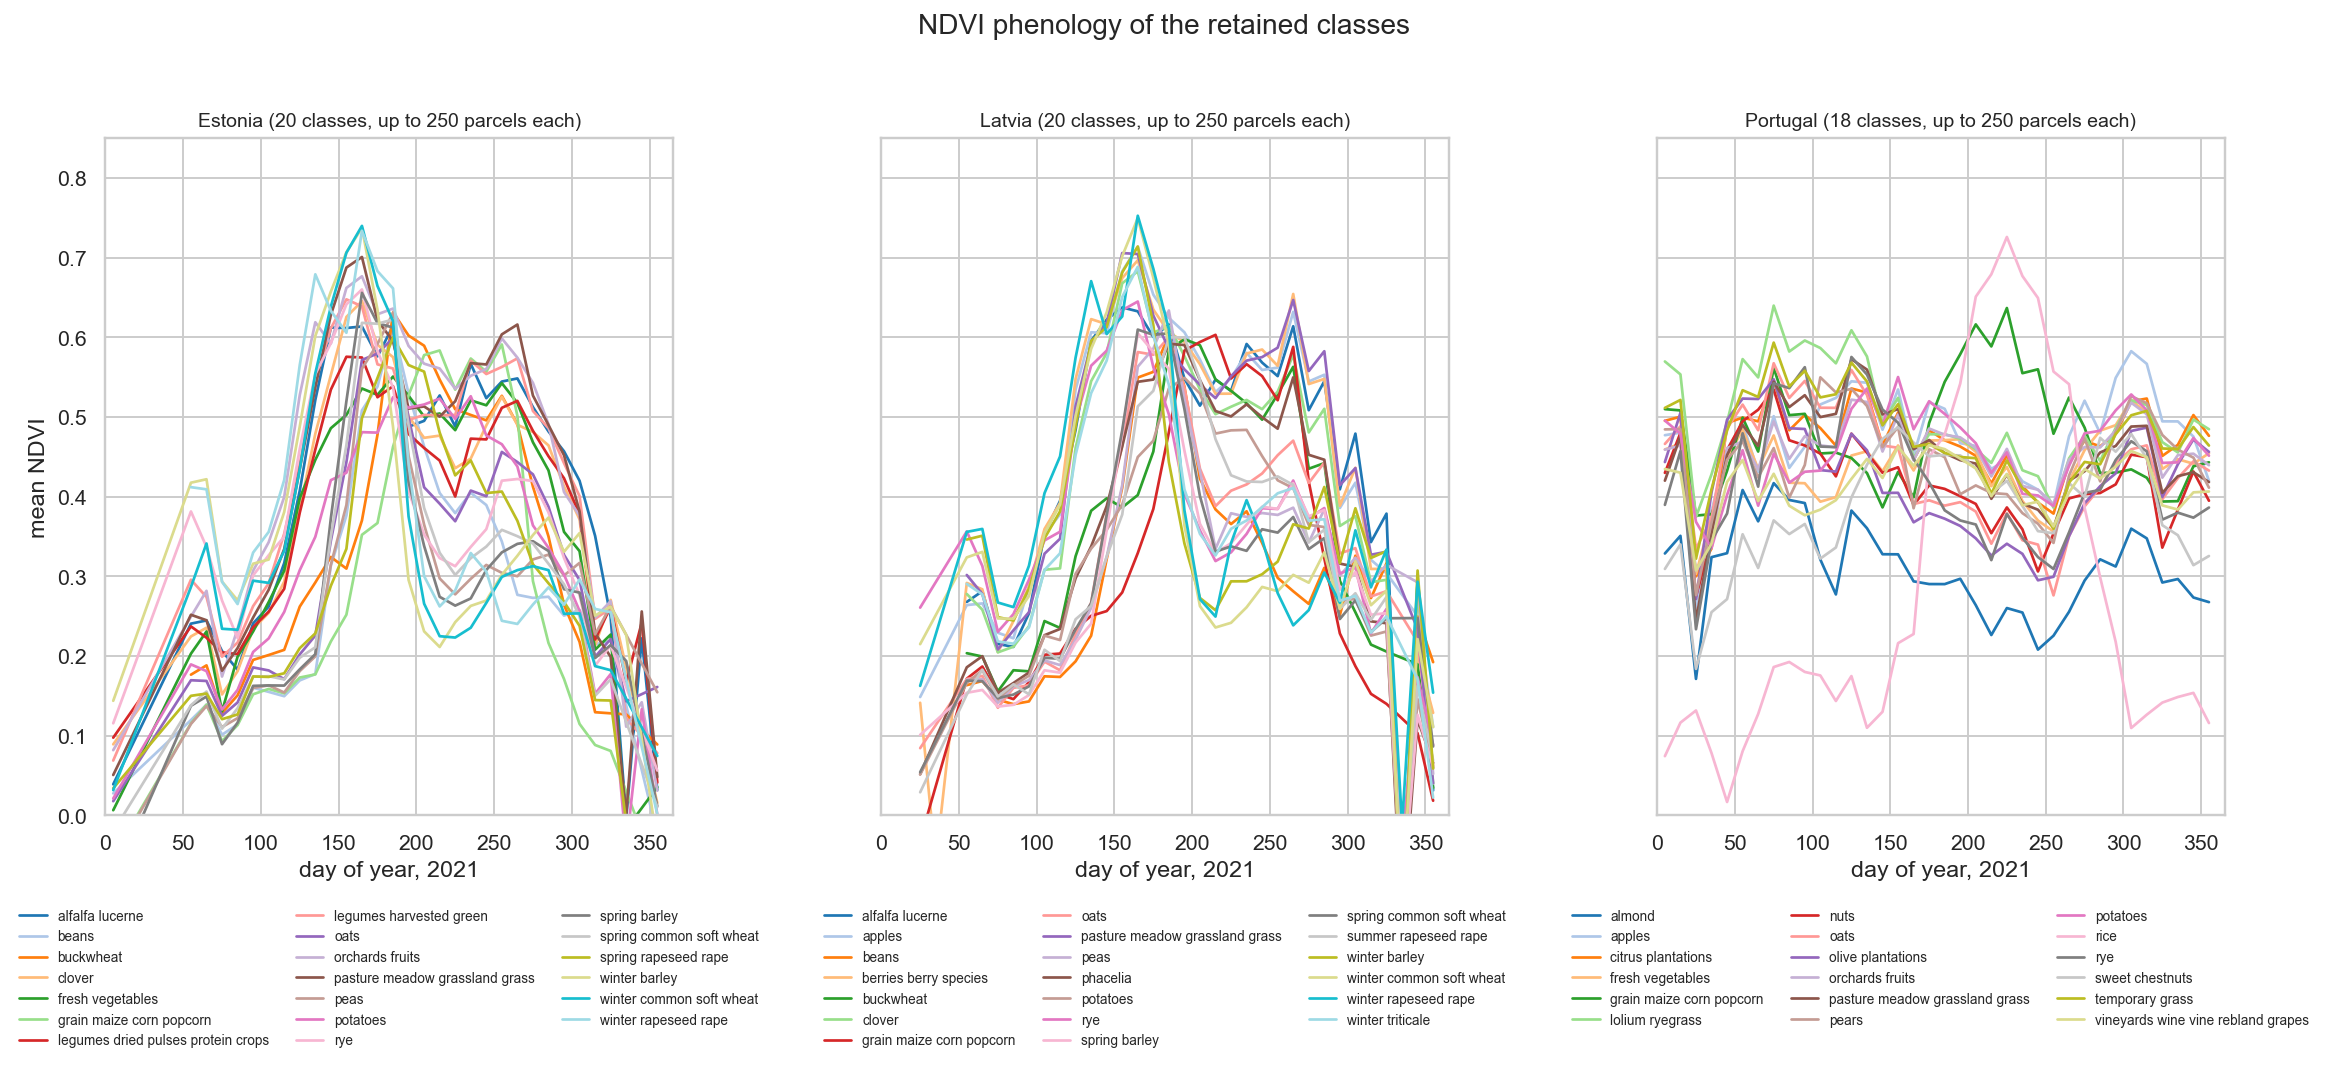

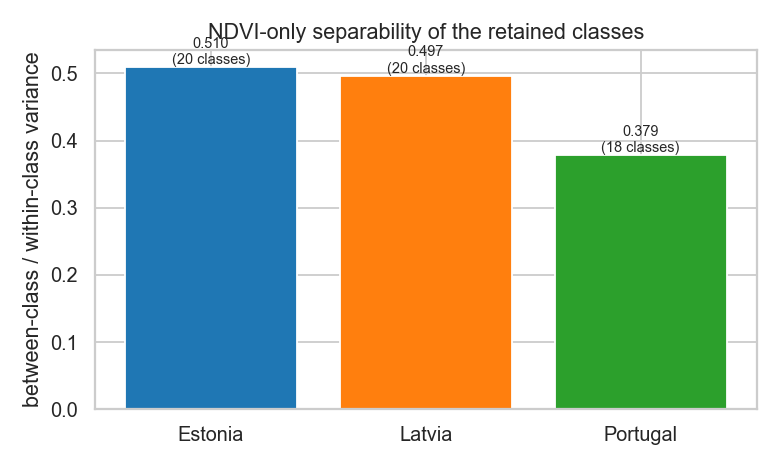

In [28]:
phen_cfg = cached(CACHE / "phenology_config.json", "_phenology.py")
phen = cached(CACHE / "phenology_profiles.parquet", "_phenology.py")
print("phenology sampling:", json.dumps(
    {k: v for k, v in phen_cfg.items() if k != "separability"}, indent=2))
print("\nNDVI-only separability of the retained classes:")
table(pd.DataFrame(phen_cfg["separability"]).T)
show("20_phenology_retained_classes.png", width=1000)
show("21_class_separability.png", width=520)

### 5.4 Are the retained classes separable at all?

For each retained class in each country a seeded sample of up to 250 parcels was drawn (14,500 parcels in total), NDVI was computed from bands B04 and B08, and the series were binned onto a ten-day grid.

The profiles behave as the agronomy predicts. The Estonian and Latvian classes all share the single-peak northern-temperate shape but separate in the timing and amplitude of the peak and, more sharply, at the shoulders: the winter cereals and winter rapeseed green up several weeks earlier than the spring variants, and the perennial fodder classes decline more slowly after the peak. Portugal shows the Mediterranean pattern, with the perennial classes (olives, vineyards, chestnuts) nearly flat across the year and the annual classes (grain maize in particular) producing a sharp summer peak against that flat background.

The ratio of between-class to within-class variance of the binned profile is 0.510 for Estonia (20 classes, F = 133.6), 0.497 for Latvia (20 classes, F = 130.2) and 0.379 for Portugal (18 classes, F = 99.9). All three are far above what class labels assigned at random would produce, so the retained classes are genuinely distinguishable from a single vegetation index before any foundation model is involved. Portugal's lower ratio is consistent with its class set being dominated by evergreen perennials whose NDVI profiles are, by construction, similar to one another.

This is a useful floor for Phase 1. Any foundation-model embedding that fails to beat a classifier trained on the binned NDVI profile alone is not contributing anything, and the NDVI profile is therefore worth adding as a third, deliberately weak reference alongside the TIMESAT phenometrics and monthly-grid baselines.

## Prior foundation-model evaluations on EuroCropsML

<!-- PLACEHOLDER: to be filled from docs/research/prior_gfm_use_eurocropsml.md -->

## 6. Conclusions and consequences for the Phase 1 design

All figures below are computed over the full 706,683-parcel catalogue unless stated otherwise.

1. **The dataset is clean and the scale is honest.** 706,683 files, 176 distinct HCAT classes, every code resolving to a name in the EuroCrops HCAT2 taxonomy. No missing coordinates, no parcel outside its national bounding box, no duplicated parcel identifier anywhere, no zero-length series. `parcel_id` can be used directly as the split key.

2. **Eleven per cent of the dataset is not crop data.** 78,710 parcels fall into catch-all, placeholder or forestry classes. The largest single item, HCAT 3399000000 (not known and other), is 29.4 % of Portugal on its own and includes landscape features and declarations with no HCAT equivalent. Excluding these is not optional.

3. **Portugal is the binding constraint everywhere.** It contributes 14.1 % of the parcels before filtering and 9.8 % after, it supports 18 classes at the recommended threshold against 28 and 34 for Estonia and Latvia, and it caps the label-budget grid.

4. **K must be an absolute count, and it must stop at 50.** The proposal's percentage definition of K would confound label scarcity with class frequency, since 1 % of Latvian grassland is 2,150 parcels and 1 % of Portuguese potatoes is 5. The absolute grid {1, 5, 10, 20, 50, 100, 200} in the work-plan table is the right form but the upper end is not supportable in Portugal; K in {1, 5, 10, 20, 50} is, with K = 100 and K = 200 available as an Estonia and Latvia extension.

5. **Aggregation buys quality, not quantity.** Rolling up to HCAT level 4 leaves the three-way intersection at 7 classes, exactly as at the native resolution, while halving the in-country class sets. What it does buy is a Portuguese side of the transfer experiment with thousands rather than hundreds of parcels per shared class. Keep the native resolution in-country, report the transfer experiment at both levels.

6. **Keep winter and spring variants separate.** Five crops have both variants, all of them absent from Portugal. Winter and spring soft wheat are the same species differing only in sowing date, so separating them is the cleanest available test of whether an encoder represents phenology rather than spectral signature.

7. **The final class scheme is 20 classes for Estonia, 20 for Latvia and 18 for Portugal**, covering 96.6 %, 97.3 % and 97.2 % of each country's filtered parcels; five classes are shared by all three countries at the native resolution and seven at level 4; the Estonia to Latvia pair shares 15 classes and is a materially easier transfer problem than either pair involving Portugal.

8. **Spatial block cross-validation should start at 20 km.** Label autocorrelation halves within about 1 km and is down to roughly a tenth of its short-range value by 20 km in the Baltics; at 20 km every retained class still occupies at least 18 distinct blocks in Portugal and at least 79 in Estonia. Portugal retains real long-range structure that reflects regional specialisation and should be handled by the cross-region design rather than by a larger block.

9. **The monthly-grid baseline should cover March to October, not the full year.** A twelve-month grid would be only 76.0 % and 78.6 % complete in Estonia and Latvia; an eight-month grid is 96.4 % and 98.8 % complete. The same winter collapse means AlphaEarth's annual embedding is, in the Baltics, effectively a growing-season composite.

10. **The retained classes are separable from NDVI alone**, with between-class to within-class variance ratios of 0.51, 0.50 and 0.38. This gives Phase 1 a cheap floor: a foundation-model embedding that cannot beat a classifier on the binned NDVI profile is contributing nothing.

### Immediate next steps

- Consume `configs/class_scheme_eurocropsml.yaml` from `src/gfm4agri/data/` so that the class lists, the exclusion rules and the protocol parameters have exactly one definition.
- Settle the K definition in the proposal text to match item 4 above.
- Implement the spatial blocking at 20 km and verify the per-fold class counts against `results/eda/cache/block_occupancy.parquet` before any model is trained.
- Decide whether fallow land and oak are reinstated; both are recorded as borderline in the configuration file with their rationale.